# Single‑Cell RNA‑seq Analysis of Parkinson Disease

### Introduction
Parkinson’s disease (PD) is a common neurodegenerative disorder characterized by progressive motor and non‑motor symptoms, with pathological features extending beyond dopaminergic neuron loss to include widespread transcriptional changes across multiple brain cell types. Recent advances in single‑cell and single‑nucleus RNA sequencing have enabled high‑resolution profiling of cellular heterogeneity in human brain tissue, allowing cell type–specific investigation of disease mechanisms that are not detectable in bulk transcriptomic analyses. The dataset used in this project (GEO accession GSE202210) provides single‑nucleus RNA‑sequencing profiles from postmortem prefrontal cortex tissue of individuals with late‑stage PD and age‑matched controls, offering a valuable resource for studying molecular and cellular alterations associated with Parkinson’s disease at single‑cell resolution.

### Project Description
This project performs a comprehensive bioinformatics analysis of the GSE202210 single‑cell RNA‑sequencing dataset to compare transcriptional profiles between Parkinson’s disease and control brain samples. Using a Scanpy‑based workflow, the analysis includes quality control, normalization, batch correction, dimensionality reduction, cell type annotation, clustering, and differential gene expression analyses to identify disease‑associated cell populations and genes. Gene enrichment analysis was further performed to identify biological processes and pathways over‑represented among the significantly differentially expressed genes. In addition, a supervised machine‑learning approach is implemented using a Random Forest classifier trained on differentially expressed genes to evaluate their ability to distinguish PD from control samples. Together, this integrated approach aims to characterize PD‑related transcriptional signatures and assess their potential relevance as biomarkers or disease predictors.

### Source
The single‑cell RNA‑sequencing data analyzed in this project were obtained from the publicly available GEO dataset GSE202210. In the original study, brain nuclei were isolated from postmortem prefrontal cortex tissue of 12 individuals with and without Parkinson’s disease (PD) using sucrose gradient ultracentrifugation. Single‑nucleus RNA‑sequencing libraries were generated using the 10x Chromium platform (10x Genomics), and sequencing was performed on an Illumina NovaSeq 6000 S4 platform. This dataset captures transcriptomic profiles of diverse brain cell types and provides a high‑resolution resource for investigating molecular changes associated with Parkinson’s disease.

Reference  
Zhu, B., Park, J.-M., Coffey, S. R., Russo, A., Hsu, I.-U., Wang, J., Zhang, L., Chandra, S. S., & Hafler, D. A. (2022). Single‑cell transcriptomic and proteomic analysis of Parkinson’s disease brains (GEO Accession No. GSE202210). National Center for Biotechnology Information. https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE202210


### Analysis Pipeline
This notebook performs a complete single‑cell RNA‑sequencing (scRNA‑seq) analysis pipeline
using Scanpy. The analysis includes:

- Loading and merging multiple 10x Genomics samples
- Quality control and filtering
- Normalization and dimensionality reduction, Batch correction
- Cell type annotation
- Clustering and marker gene identification
- Differential expression analysis (PD vs Control)
- Gene Enrichment Analysis 
- Machine‑learning classification using Random Forest

The goal is to identify cell populations, disease‑associated genes,
and predictive biomarkers for Parkinson’s Disease (PD).

### Import Required Libraries

Basic Python and Scanpy libraries are imported to handle
data processing, file management, and single‑cell analysis.

In [1]:
# Single-cell analysis
import scanpy as sc

# Data manipulation
import pandas as pd

# File and path handling
import os

### Load One Sample for Exploration

A single 10x Genomics sample is loaded to inspect
the structure of the dataset, including cells, genes,
and metadata.

In [ ]:
# Path to a single sample gene matrix

sample_path = "GSE202210_RAW/sample 1/GSM6106340_HSDG07HC_genes.tsv.gz"

# Read 10x Genomics formatted data
adata = sc.read_10x_mtx(
    "GSE202210_RAW/GSM6106340_HSDG07HC",
    var_names='gene_symbols',
    cache=True
)

# Display AnnData object summary
adata

AnnData object with n_obs × n_vars = 4813 × 33538
    var: 'gene_ids', 'feature_types'

### Inspect Gene and Cell Metadata

Examine gene names (`var`) and cell annotations (`obs`)
to understand dataset dimensions and structure.

In [ ]:
# Gene names
adata.var_names

Index(['MIR1302-2HG', 'FAM138A', 'OR4F5', 'AL627309.1', 'AL627309.3',
       'AL627309.2', 'AL627309.4', 'AL732372.1', 'OR4F29', 'AC114498.1',
       ...
       'AC007325.2', 'BX072566.1', 'AL354822.1', 'AC023491.2', 'AC004556.1',
       'AC233755.2', 'AC233755.1', 'AC240274.1', 'AC213203.1', 'FAM231C'],
      dtype='object', length=33538)

In [ ]:
# Dataset dimensions (cells × genes)
adata.shape

(4813, 33538)

In [ ]:
# Preview gene annotations
adata.var.head()   # genes

,gene_ids,feature_types
MIR1302-2HG,ENSG00000243485,Gene Expression
FAM138A,ENSG00000237613,Gene Expression
OR4F5,ENSG00000186092,Gene Expression
AL627309.1,ENSG00000238009,Gene Expression
AL627309.3,ENSG00000239945,Gene Expression


In [ ]:
# Preview cell annotations
adata.obs.head()   # cells

""
AAACCCAAGAATAACC-1
AAACCCAAGTCATCCA-1
AAACCCAGTAATCAGA-1
AAACCCATCCATTCGC-1
AAACGAAAGGAGTACC-1


### Load and Merge All Samples

All samples are loaded individually, annotated with
sample name and condition (PD or Control), then merged
into a single AnnData object for downstream analysis.

In [2]:
# List of GSM sample IDs
samples = [
    "GSM6106340_HSDG07HC",
    "GSM6106341_hsDG101HC",
    "GSM6106342_HSDG10HC",
    "GSM6106343_hsDG13HC",
    "GSM6106344_hsDG142PD",
    "GSM6106345_HSDG148PD",
    "GSM6106346_hsDG151PD",
    "GSM6106347_hsDG197PD",
    "GSM6106348_HSDG199PD",
    "GSM6106349_hsDG208PD",
    "GSM6106350_hsDG30HC",
    "GSM6106351_hsDG99HC"
]

adata_list = []

for s in samples:
    path = f"GSE202210_RAW/{s}"   # adjust if needed
    
    
    # Read each sample
    ad = sc.read_10x_mtx(
        path,
        var_names='gene_symbols',
        cache=True
    )
    
    # store sample name
    ad.obs['sample'] = s
    

    # Assign condition based on sample ID
    if "HC" in s:
        ad.obs['condition'] = 'control'
    elif "PD" in s:
        ad.obs['condition'] = 'PD'
    else:
        ad.obs['condition'] = 'unknown'
    
    adata_list.append(ad)


# Concatenate all samples
adata = adata_list[0].concatenate(adata_list[1:])

adata

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3180\708087388.py:46: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adata_list[0].concatenate(adata_list[1:])


AnnData object with n_obs × n_vars = 77983 × 33538
    obs: 'sample', 'condition', 'batch'
    var: 'gene_ids', 'feature_types'

### Save Combined Dataset

Saving intermediate results allows reproducibility
and prevents re‑reading raw data multiple times.

In [3]:
# Save combined raw dataset
adata.write("combined_raw.h5ad")

In [ ]:
# Reload saved dataset
adata = sc.read_h5ad("combined_raw.h5ad")
adata

AnnData object with n_obs × n_vars = 77983 × 33538
    obs: 'sample', 'condition', 'batch'
    var: 'gene_ids', 'feature_types'

## 1. Dataset Summary

Explore metadata distributions, including condition,
sample batches, and gene feature types.

In [ ]:
#view cell annotations
adata.obs

,sample,condition,batch
AAACCCAAGAATAACC-1-0,GSM6106340_HSDG07HC,control,0
AAACCCAAGTCATCCA-1-0,GSM6106340_HSDG07HC,control,0
AAACCCAGTAATCAGA-1-0,GSM6106340_HSDG07HC,control,0
AAACCCATCCATTCGC-1-0,GSM6106340_HSDG07HC,control,0
AAACGAAAGGAGTACC-1-0,GSM6106340_HSDG07HC,control,0
...,...,...,...
TTTGTTGGTTCATCTT-1-11,GSM6106351_hsDG99HC,control,11
TTTGTTGTCATCTATC-1-11,GSM6106351_hsDG99HC,control,11
TTTGTTGTCCTCGATC-1-11,GSM6106351_hsDG99HC,control,11
TTTGTTGTCGTTAGAC-1-11,GSM6106351_hsDG99HC,control,11


In [ ]:
#view gene annotations
adata.var

,gene_ids,feature_types
MIR1302-2HG,ENSG00000243485,Gene Expression
FAM138A,ENSG00000237613,Gene Expression
OR4F5,ENSG00000186092,Gene Expression
AL627309.1,ENSG00000238009,Gene Expression
AL627309.3,ENSG00000239945,Gene Expression
...,...,...
AC233755.2,ENSG00000277856,Gene Expression
AC233755.1,ENSG00000275063,Gene Expression
AC240274.1,ENSG00000271254,Gene Expression
AC213203.1,ENSG00000277475,Gene Expression


In [ ]:
# Dataset dimensions (cells × genes)
adata.shape

(77983, 33538)

There are 77983 cells and 33538 genes. 

In [ ]:
# Cell counts per condition
adata.obs['condition'].value_counts()

condition
PD         42716
control    35267
Name: count, dtype: int64

There are 42716 samples of Parkinson Disease (PD) and 35267 samples of control (normal people)

In [ ]:
# Cell counts per sample
adata.obs['sample'].value_counts()

sample
GSM6106347_hsDG197PD    10440
GSM6106345_HSDG148PD     9071
GSM6106344_hsDG142PD     8316
GSM6106342_HSDG10HC      7455
GSM6106348_HSDG199PD     7365
GSM6106350_hsDG30HC      6246
GSM6106341_hsDG101HC     5863
GSM6106351_hsDG99HC      5798
GSM6106349_hsDG208PD     5633
GSM6106343_hsDG13HC      5092
GSM6106340_HSDG07HC      4813
GSM6106346_hsDG151PD     1891
Name: count, dtype: int64

In [ ]:
# Gene feature types
adata.var['feature_types'].value_counts()

feature_types
Gene Expression    33538
Name: count, dtype: int64

## 2. Quality Control Metrics

Mitochondrial gene content is calculated as an
indicator of cell quality.

In [ ]:
# Identify mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var['mt']

MIR1302-2HG    False
FAM138A        False
OR4F5          False
AL627309.1     False
AL627309.3     False
               ...  
AC233755.2     False
AC233755.1     False
AC240274.1     False
AC213203.1     False
FAM231C        False
Name: mt, Length: 33538, dtype: bool

In [ ]:
# Compute QC metrics
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    inplace=True
)

In [ ]:
# Preview QC metrics
adata

AnnData object with n_obs × n_vars = 77983 × 33538
    obs: 'sample', 'condition', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

In [ ]:
# Preview QC metrics
adata.obs.head()

,sample,condition,batch,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt
AAACCCAAGAATAACC-1-0,GSM6106340_HSDG07HC,control,0,1262,7.141245,1800.0,7.496098,17.611111,25.611111,36.722222,57.666667,12.0,2.564949,0.666667
AAACCCAAGTCATCCA-1-0,GSM6106340_HSDG07HC,control,0,3578,8.182839,9864.0,9.196749,20.802920,28.892944,38.422547,54.176805,23.0,3.178054,0.233171
AAACCCAGTAATCAGA-1-0,GSM6106340_HSDG07HC,control,0,2006,7.604396,3808.0,8.245122,24.238445,31.643908,41.097689,58.665966,90.0,4.510859,2.363446
AAACCCATCCATTCGC-1-0,GSM6106340_HSDG07HC,control,0,3516,8.165364,9848.0,9.195126,21.242892,29.142973,39.053615,54.914703,90.0,4.510859,0.913891
AAACGAAAGGAGTACC-1-0,GSM6106340_HSDG07HC,control,0,6722,8.813290,28887.0,10.271181,19.693980,26.659051,34.773427,48.454322,314.0,5.752573,1.086994


In [ ]:
# Preview QC metrics
adata.var.head()

,gene_ids,feature_types,mt,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
MIR1302-2HG,ENSG00000243485,Gene Expression,False,18,0.000231,0.000231,99.976918,18.0,2.944439
FAM138A,ENSG00000237613,Gene Expression,False,0,0.000000,0.000000,100.000000,0.0,0.000000
OR4F5,ENSG00000186092,Gene Expression,False,1,0.000013,0.000013,99.998718,1.0,0.693147
AL627309.1,ENSG00000238009,Gene Expression,False,3986,0.054884,0.053431,94.888630,4280.0,8.361942
AL627309.3,ENSG00000239945,Gene Expression,False,0,0.000000,0.000000,100.000000,0.0,0.000000


### Visualize Quality Control Metrics

Violin plots and scatter plots help determine
filtering thresholds.

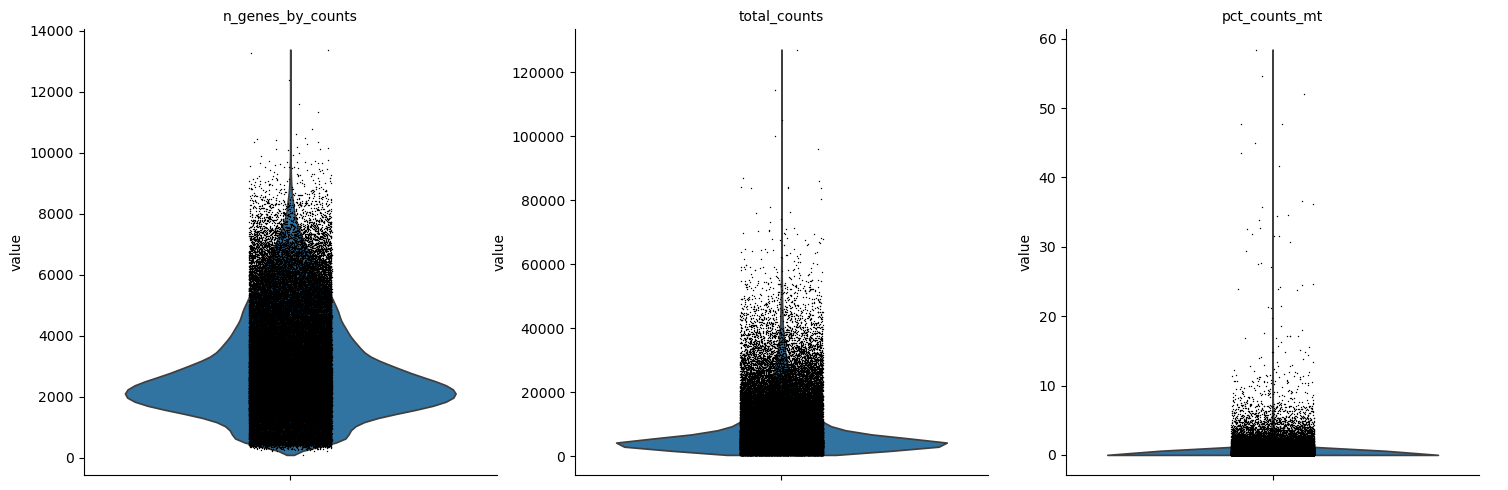

In [ ]:
# Violin plots
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    multi_panel=True
)

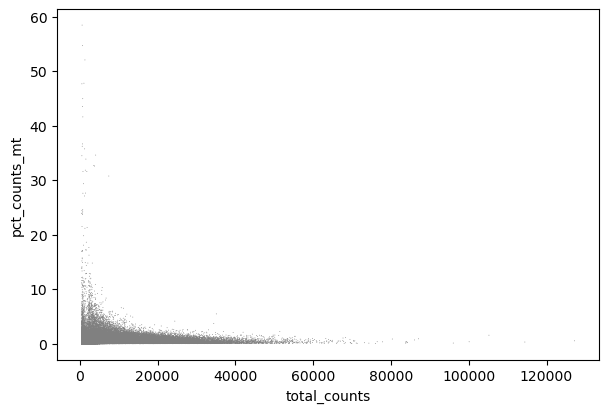

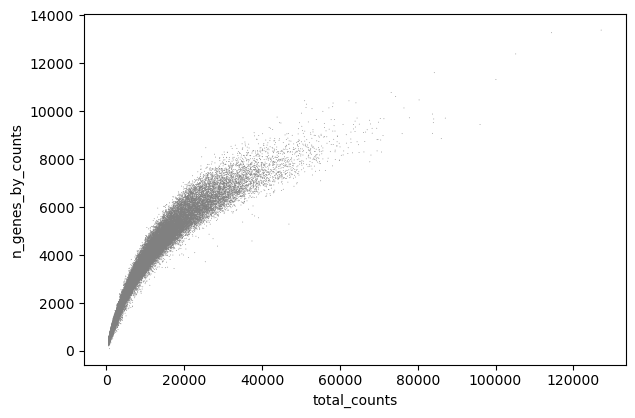

In [ ]:
# Scatter plots
sc.pl.scatter(adata, x="total_counts", y="pct_counts_mt")
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts")

### Cell Filtering Based on Quality Control Metrics

Cells with too few genes, excessive counts,
or high mitochondrial content are removed.

Based on the inspection of the quality control **violin plots** and **scatter plots** (showing distributions of gene counts, total UMI counts, and mitochondrial gene percentages), empirical threshold values were selected to remove low‑quality and outlier cells. 

Specifically, cells with very low or excessively high numbers of detected genes, low total counts, or high mitochondrial gene content were excluded. These thresholds reflect the natural cutoffs observed in the QC visualizations and help retain biologically meaningful, high‑quality cells for downstream analysis.

In [8]:
adata = adata[
    (adata.obs.n_genes_by_counts > 200) &
    (adata.obs.n_genes_by_counts < 6000) &
    (adata.obs.total_counts > 1000) &
    (adata.obs.pct_counts_mt < 10),
    :
]

In [ ]:
# Dataset dimensions after filtering
adata.shape

(69339, 33538)

After filtering, 69339 cells and 33538 genes are left. 

## 3. Normalization and Highly Variable Genes, Dmensionality Reduction, Batch Correction

Expression values are normalized, log‑transformed,
and the most informative genes are selected.

### Dimensionality Reduction

Then, Principal Component Analysis (PCA) is used for dimensionality reduction and UMAP
for visualization and clustering.

In [ ]:
# Normalize total counts
sc.pp.normalize_total(adata, target_sum=1e4)

# Log transformation
sc.pp.log1p(adata)

# Identify highly variable genes
sc.pp.highly_variable_genes(adata, n_top_genes=2000)


# Subset to HVGs
adata = adata[:, adata.var.highly_variable]

# Scale data
sc.pp.scale(adata, max_value=10)

# 4. PCA
sc.tl.pca(adata)


In [ ]:
# Save after PCA

adata.write("adata_after_pca.h5ad")

### Batch Correction

This Harmony batch correction was performed in the separate notebook `Harmony Batch Correction.ipynb` to avoid library dependency conflicts in this analysis workflow.
The corrected dataset is reloaded here from `combined_harmony_corrected.h5ad` for downstream processing.

In [2]:
# Reload the batch-corrected dataset
adata = sc.read_h5ad("combined_harmony_corrected.h5ad")

In [3]:
#check the data
adata

AnnData object with n_obs × n_vars = 69339 × 2000
    obs: 'sample', 'condition', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'pca'
    obsm: 'X_pca', 'X_pca_harmony'
    varm: 'PCs'

## 4. Cell Type Annotation 

This cell typing annotation was completed in the separate notebook `Cell Typing.ipynb` to keep the module dependencies isolated from this main analysis workflow.
The final cell type predictions are loaded here from `celltypist_results.csv` for downstream integration.

In [44]:
adata

AnnData object with n_obs × n_vars = 69339 × 2000
    obs: 'sample', 'condition', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden', 'celltypist_prediction', 'majority_voting'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'pca', 'neighbors', 'umap', 'batch_colors', 'condition_colors', 'leiden', 'rank_leiden', 'rank_condition', 'leiden_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [4]:
# 1. Load the saved prediction CSV from the other notebook
import pandas as pd
predictions_df = pd.read_csv("celltypist_results.csv", index_col=0)

# 2. Reindex matches the cells safely using cell barcodes
# If a barcode isn't found, it safely places NaN instead of crashing.
adata.obs['celltypist_prediction'] = predictions_df['predicted_labels'].reindex(adata.obs_names).values
adata.obs['majority_voting'] = predictions_df['majority_voting'].reindex(adata.obs_names).values

In [6]:
adata.obs['majority_voting'].value_counts()

majority_voting
Oligo MOG OPALIN           23387
L2-3 CUX2 ACVR1C THSD7A     7909
OPC PDGFRA PCDH15           5099
Astro AQP4 SLC1A2           3630
Astro AQP4 OSMR             2980
                           ...  
Oligo MOG FRY                 40
L2-3 CUX2 ACVR1C INHBA        36
InN PVALB PDE3A               25
L5-6 FEZF2 NXPH2 SORCS3       17
L2-3 CUX2 PLCXD3              14
Name: count, Length: 67, dtype: int64

In [5]:
# Check the first 5 cells to make sure predictions are populated
print(adata.obs[['celltypist_prediction', 'majority_voting']].head())

# Check if there are any missing cells after mapping
print("\nMissing predictions:", adata.obs['majority_voting'].isna().sum())

                        celltypist_prediction          majority_voting
AAACCCAAGAATAACC-1-0       VLMC COL1A2 VLMCA8      VLMC COL1A2 SLC13A3
AAACCCAAGTCATCCA-1-0  L2-3 CUX2 ACVR1C THSD7A  L2-3 CUX2 ACVR1C THSD7A
AAACCCAGTAATCAGA-1-0           InN VIP CLSTN2           InN VIP CLSTN2
AAACCCATCCATTCGC-1-0   L3-5 RORB GABRG1 KCNH7   L3-5 RORB GABRG1 KCNH7
AAACGAACATGAAGCG-1-0        OPC PDGFRA PCDH15        OPC PDGFRA PCDH15

Missing predictions: 0


In [16]:
#check the number of cell types
len(adata.obs['majority_voting'].unique())

67

There are 67 cell types and they are grouped into their relevant major cell class like Oligodendrocytes, Macroglia for clear visualization and interpretation.

For this, mapping of cell types to major cell class is done as follows:

In [ ]:
# Create major cell class mapping dictory based on your exact labels

major_class_map = {

    # =========================
    # Oligodendrocyte lineage
    # =========================
    "Oligo MOG OPALIN": "Oligodendrocytes",
    "Oligo MOG GSN": "Oligodendrocytes",
    "Oligo MOG FRY": "Oligodendrocytes",
    "OPC PDGFRA PCDH15": "OPC",
    "COP GPR17 SOX4": "OPC",

    # =========================
    # Astrocytes
    # =========================
    "Astro AQP4 SLC1A2": "Astrocytes",
    "Astro AQP4 OSMR": "Astrocytes",
    "Astro GFAP FABP7": "Astrocytes",
    "Astro GFAP AQP1": "Astrocytes",

    # =========================
    # Microglia
    # =========================
    "Micro P2RY12 APBB1IP": "Microglia",
    "Micro P2RY12 GLDN": "Microglia",
    "Micro P2RY12 CCL3": "Microglia",

    # =========================
    # Macrophages
    # =========================
    "Macro F13A1 COLEC12": "Macrophages",

    # =========================
    # Endothelial & vascular
    # =========================
    "Endo CLDN5 SLC7A5": "Endothelial/Vascular",
    "VLMC COL1A2 SLC13A3": "Endothelial/Vascular",

    # =========================
    # T cells
    # =========================
    "T SKAP1 CD247": "Peripheral Immune Cells",

    # =========================
    # Excitatory neurons
    # =========================
    "L2-3 CUX2 ACVR1C THSD7A": "Excitatory Neurons",
    "L2-3 CUX2 NTNG1 PALMD": "Excitatory Neurons",
    "L2-3 CUX2 NTNG1 COL5A2": "Excitatory Neurons",
    "L2-4 CUX2 RORB CLMN": "Excitatory Neurons",
    "L2-3 CUX2 ACVR1C INHBA": "Excitatory Neurons",
    "L2-3 CUX2 PLCXD3": "Excitatory Neurons",

    "L3-5 RORB GABRG1 KCNH7": "Excitatory Neurons",
    "L3-5 RORB MKX GRIN3A": "Excitatory Neurons",
    "L3-5 RORB GABRG1 PTPRO": "Excitatory Neurons",
    "L3-5 RORB PCBP3 IL1RAPL2": "Excitatory Neurons",
    "L3-5 RORB MKX DCC": "Excitatory Neurons",
    "L3-5 RORB TNNT2 TSHZ2": "Excitatory Neurons",
    "L3-5 RORB MKX SCN5A": "Excitatory Neurons",
    "L3-5 RORB GABRG1 PLCH1": "Excitatory Neurons",

    "L5 FEZF2 BCL11B POU3F1": "Excitatory Neurons",
    "L5-6 FEZF2 NXPH2 CDH8": "Excitatory Neurons",
    "L5-6 FEZF2 NXPH2 SORCS3": "Excitatory Neurons",

    "L6 OPRK1 THEMIS RGS6": "Excitatory Neurons",
    "L6 OPRK1 SMYD1 SNTB1": "Excitatory Neurons",
    "L6 FEZF2 SYT6 PTPRT": "Excitatory Neurons",
    "L6 FEZF2 SYT6 CDH9": "Excitatory Neurons",
    "L6 FEZF2 DCBLD1 MITF": "Excitatory Neurons",

    "PC P2RY14 GRM8": "Excitatory Neurons",

    # =========================
    # Inhibitory interneurons
    # =========================
    "InN PVALB ANOS1": "Inhibitory Interneurons",
    "InN PVALB GRIN2C": "Inhibitory Interneurons",
    "InN PVALB PIEZO2": "Inhibitory Interneurons",
    "InN PVALB HPSE": "Inhibitory Interneurons",
    "InN PVALB SYT2": "Inhibitory Interneurons",
    "InN PVALB PRKCH": "Inhibitory Interneurons",
    "InN PVALB PDE3A": "Inhibitory Interneurons",

    "InN SST TRPC7": "Inhibitory Interneurons",
    "InN SST STK32A": "Inhibitory Interneurons",
    "InN SST FREM1": "Inhibitory Interneurons",
    "InN SST HTR2C": "Inhibitory Interneurons",
    "InN SST THSD7B": "Inhibitory Interneurons",
    "InN SST PLPP4": "Inhibitory Interneurons",

    "InN VIP HS3ST3B1": "Inhibitory Interneurons",
    "InN VIP EXPH5": "Inhibitory Interneurons",
    "InN VIP CLSTN2": "Inhibitory Interneurons",
    "InN VIP SCML4": "Inhibitory Interneurons",
    "InN VIP EGF": "Inhibitory Interneurons",
    "InN VIP FREM2": "Inhibitory Interneurons",
    "InN VIP ADAM12": "Inhibitory Interneurons",
    "InN VIP MEGF11 LHFP": "Inhibitory Interneurons",

    "InN LAMP5 BMP7": "Inhibitory Interneurons",
    "InN LAMP5 RELN": "Inhibitory Interneurons",
    "InN LAMP5 LHX6 TAC1": "Inhibitory Interneurons",

    "InN ADARB2 RGS10": "Inhibitory Interneurons",
    "InN ADARB2 SFRP2": "Inhibitory Interneurons",
    "InN ADARB2 FAM19A1": "Inhibitory Interneurons",
    "InN ADARB2 COL5A2": "Inhibitory Interneurons",
}

In [ ]:
# Apply Mapping to majority voting column using this dictionary
adata.obs["cell_major_class"] = (
    adata.obs["majority_voting"]
    .map(major_class_map)
)

In [17]:
# Check for Unmapped Labels
unmapped = adata.obs.loc[
    adata.obs["cell_major_class"].isna(),
    "majority_voting"
].unique()

print("Unmapped labels:")
print(unmapped)

Unmapped labels:
[]


There is no unmapped labels and all cells are mapped to major class.

In [ ]:
#check the count of major cell type (class) 
adata.obs["cell_major_class"].value_counts()

cell_major_class
Oligodendrocytes           23846
Excitatory Neurons         16194
Inhibitory Interneurons    11266
Astrocytes                  7497
OPC                         5152
Microglia                   2559
Macrophages                 1956
Endothelial/Vascular         614
Peripheral Immune Cells      255
Name: count, dtype: int64

After cell type annotation, the following steps are conducted to visulize the UMAP plots.

In [19]:
# Compute neighborhood graph
sc.pp.neighbors(adata, use_rep="X_pca_harmony")


# UMAP embedding
sc.tl.umap(adata)

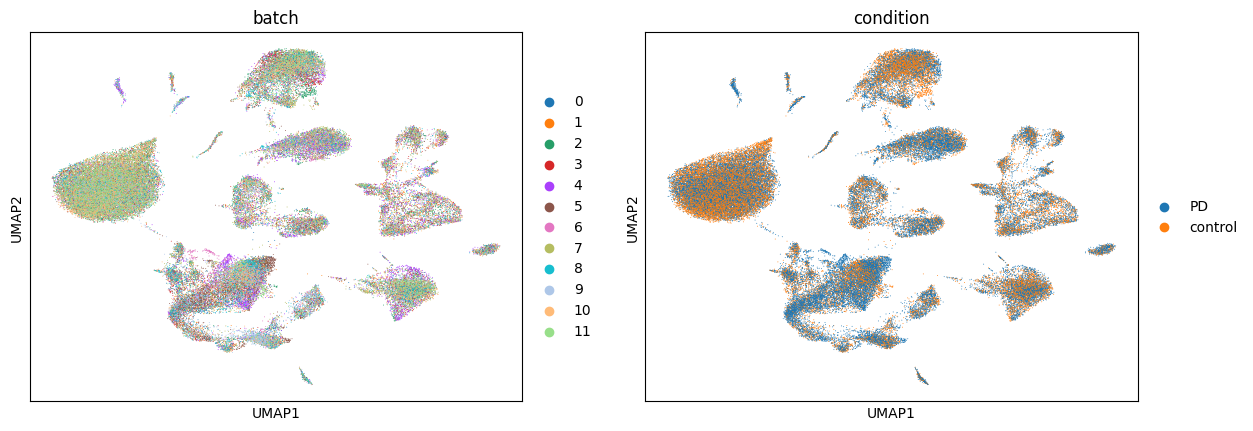

In [78]:
# UMAP visualization
sc.pl.umap(adata, color=["batch", "condition"])

The UMAP embedding shows substantial overlap between Parkinson’s disease and control cells, indicating shared cellular populations, while the presence of PD‑enriched clusters suggests condition‑specific transcriptional states associated with Parkinson’s disease.

The batch UMAP shows good mixing of cells from different batches across clusters, suggesting that batch effects are minimal and do not strongly drive the observed transcriptional structure of the data.



## 5. Clustering and Marker Gene Identification

Leiden clustering is used to identify transcriptionally
distinct cell populations.
Then, marker genes are extracted for each cluster.

In [22]:
# Preview dataset 
adata

AnnData object with n_obs × n_vars = 69339 × 2000
    obs: 'sample', 'condition', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'celltypist_prediction', 'majority_voting', 'cell_major_class'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'pca', 'neighbors', 'umap', 'batch_colors', 'condition_colors', 'cell_major_class_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

### Leiden Clustering
The `sc.tl.leiden` function applies the Leiden community detection algorithm to cluster cells based on their nearest-neighbor graph. This method is an improvement over the Louvain algorithm, designed to produce more robust and well-separated clusters.

- `adata`: The AnnData object containing the preprocessed single-cell data.
- `flavor="igraph"`: Specifies the implementation of the Leiden algorithm to use (in this case, the `igraph` library).
- `n_iterations=2`: Sets the number of iterations for the algorithm, influencing the granularity of the clusters.
- `directed=False`: Indicates that the graph is undirected, which is typical for single-cell clustering based on Euclidean distances.

In [23]:
#leiden clustering
sc.tl.leiden(
    adata,
    flavor="igraph",
    n_iterations=2,
    directed=False
)

A cross-tabulation is generated to compare the results of Leiden clustering with the predicted major cell type annotations. It helps assess how well the unsupervised Leiden clusters align with biologically defined cell types, providing a count of cells for each cluster-cell type combination.

In [ ]:
# Compare Leiden Clusters vs. CellTypist Labels
# Display a cross-tabulation to see how Leiden clusters match predicted cell types
cluster_vs_celltypist = pd.crosstab(adata.obs['leiden'], adata.obs['cell_major_class'])
print("Leiden clusters vs. CellTypist labels:")
print(cluster_vs_celltypist)

Leiden clusters vs. CellTypist labels:
cell_major_class  Astrocytes  Endothelial/Vascular  Excitatory Neurons  \
leiden                                                                   
0                          1                   187                 168   
1                          0                     5                7022   
2                          1                   101                1495   
3                          0                     4                   7   
4                          0                     0                3518   
5                          0                     1                2089   
6                          0                     0                   3   
7                          2                     0                   0   
8                          0                     1                1183   
9                          0                     0                   3   
10                         0                     1                   2   

Marker genes per cluster  
Cluster‑specific marker genes were identified by comparing gene expression across Leiden clusters using the Wilcoxon rank‑sum test. This analysis highlights genes that are significantly enriched in each cluster, enabling biological interpretation and cell‑type annotation of the identified cell populations.

Marker genes by condition  
Differential gene expression analysis between Parkinson’s disease (PD) and control samples was performed using the Wilcoxon rank‑sum test. This approach identifies genes that are significantly up‑ or down‑regulated between conditions, providing insight into disease‑associated transcriptional changes.


In [ ]:
# Marker genes per cluster
sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    method="wilcoxon",
    key_added="rank_leiden"
)

# Marker genes by condition
sc.tl.rank_genes_groups(
    adata,
    groupby="condition",
    method="wilcoxon",
    key_added="rank_condition"
)

Marker by Cell type/class  
Then, identify specific marker genes for each predicted cell type (`cell_major_class`) using the Wilcoxon rank-sum test. These genes are characteristic of each cell type and help in understanding their unique biological functions.

In [ ]:
# Marker genes per predicted CellTypist cell type
# This identifies specific genes that define the predicted cell types in your dataset
sc.tl.rank_genes_groups(
    adata,
    groupby="cell_major_class",
    method="wilcoxon",
    key_added="rank_cell_type"
)

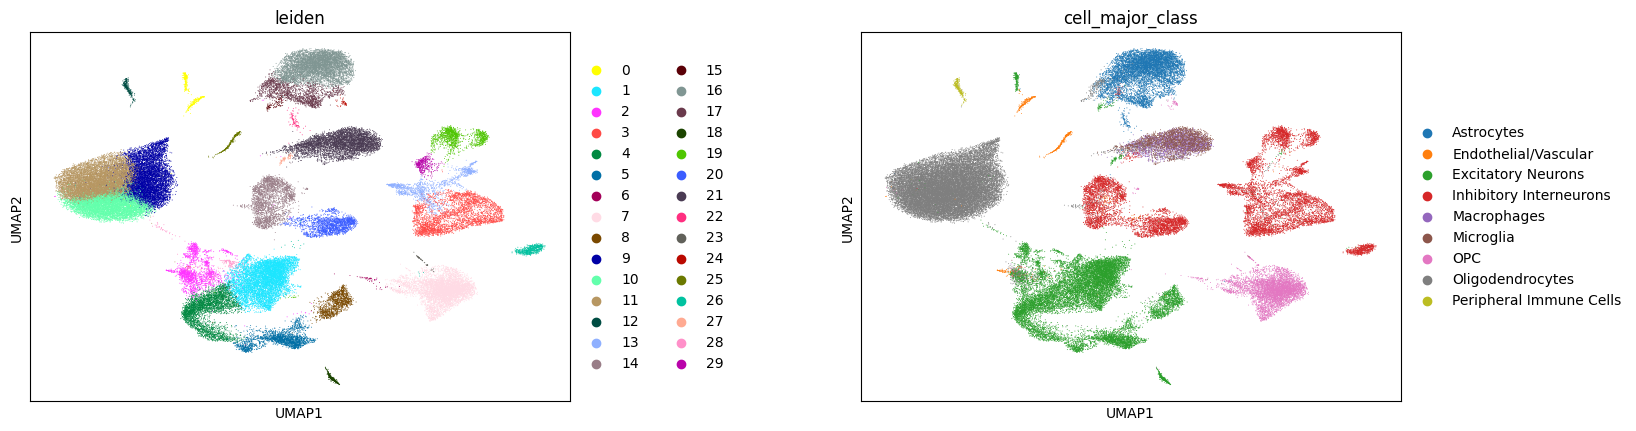

In [ ]:
# Side-by-side UMAP: Leiden vs. Cell types/major class
# This allows you to immediately see which Leiden clusters align with each cell type
sc.pl.umap(
    adata, 
    color=["leiden", "cell_major_class"], 
    wspace=0.4
)

The side-by-side UMAP plots for Leiden clustering and major cell classes visually assess the cell type annotation process. Leiden clustering groups cells based on transcriptional similarity, while major cell classes are assigned via known markers and computational prediction.

**Interpretation:**

-   **Consistency:** Well-aligned Leiden clusters with specific major cell classes indicate successful capture of biological distinctions. Discrepancies might suggest fine-grained heterogeneity or issues with clustering/annotation.

-   **Visual Alignment:** Strong visual overlap and distinct boundaries between major cell classes within Leiden clusters confirm robust and biologically meaningful data partitioning.

-   **Refinement:** If a Leiden cluster spans multiple major cell classes, it implies finer distinctions within broader types. Conversely, a single major cell class split across multiple Leiden clusters points to transcriptionally distinct sub-populations.

Overall, these UMAPs validate that the clustering and cell type annotation procedures have produced coherent cellular populations, providing a strong foundation for downstream differential expression analysis.

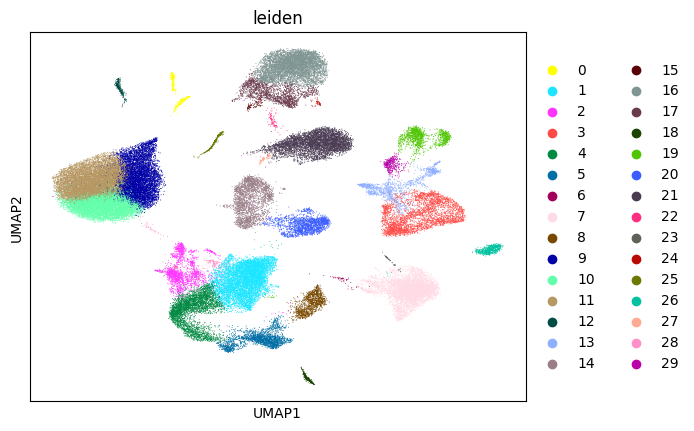

In [ ]:
# Plot leiden clusters for better visuality 
sc.pl.umap(adata, color="leiden")

**Interpretation:**
The Leiden UMAP shows well-defined clusters based on transcriptional similarity, indicating the successful identification of distinct cellular populations or cell states. This forms the basis for downstream marker gene analysis and biological interpretation.

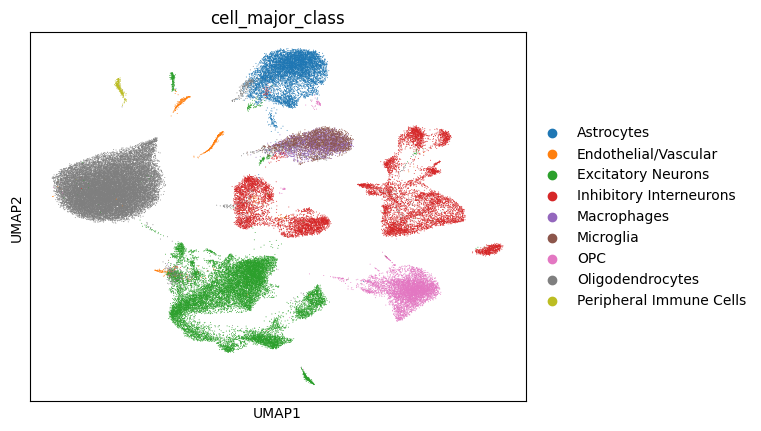

In [ ]:
# Plot major cell class/type clusters for better visuality 
sc.pl.umap(adata, color="cell_major_class")

**Interpretation:** This UMAP plot helps confirm whether the major population of the cell types identified (e.g., Oligodendrocytes, Astrocytes, Excitatory & Inhibitory Neurons) form distinct and coherent clusters, indicating successful cell type classification.

This UMAP plot visualizes the dataset, with each cell colored according to its `condition` (Parkinson's Disease or Control). It helps to visually assess how well the PD and control samples are separated.

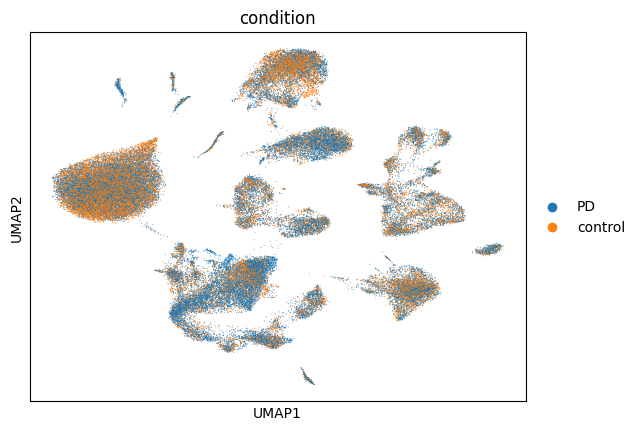

In [ ]:
#plot condition clusters for better visuality
sc.pl.umap(
    adata, 
    color="condition"
)

**Interpretation:** 
This UMAP plot visualizes the dataset with cells colored by `condition` (Parkinson's Disease or Control). It helps assess the visual separation of PD and control samples, showing potential condition-specific transcriptional states and shared cellular populations.

Then, visualizes the top 15 marker genes for each Leiden cluster. It helps to quickly identify the most characteristic genes that define each cell population, providing insights into their unique biological identities.

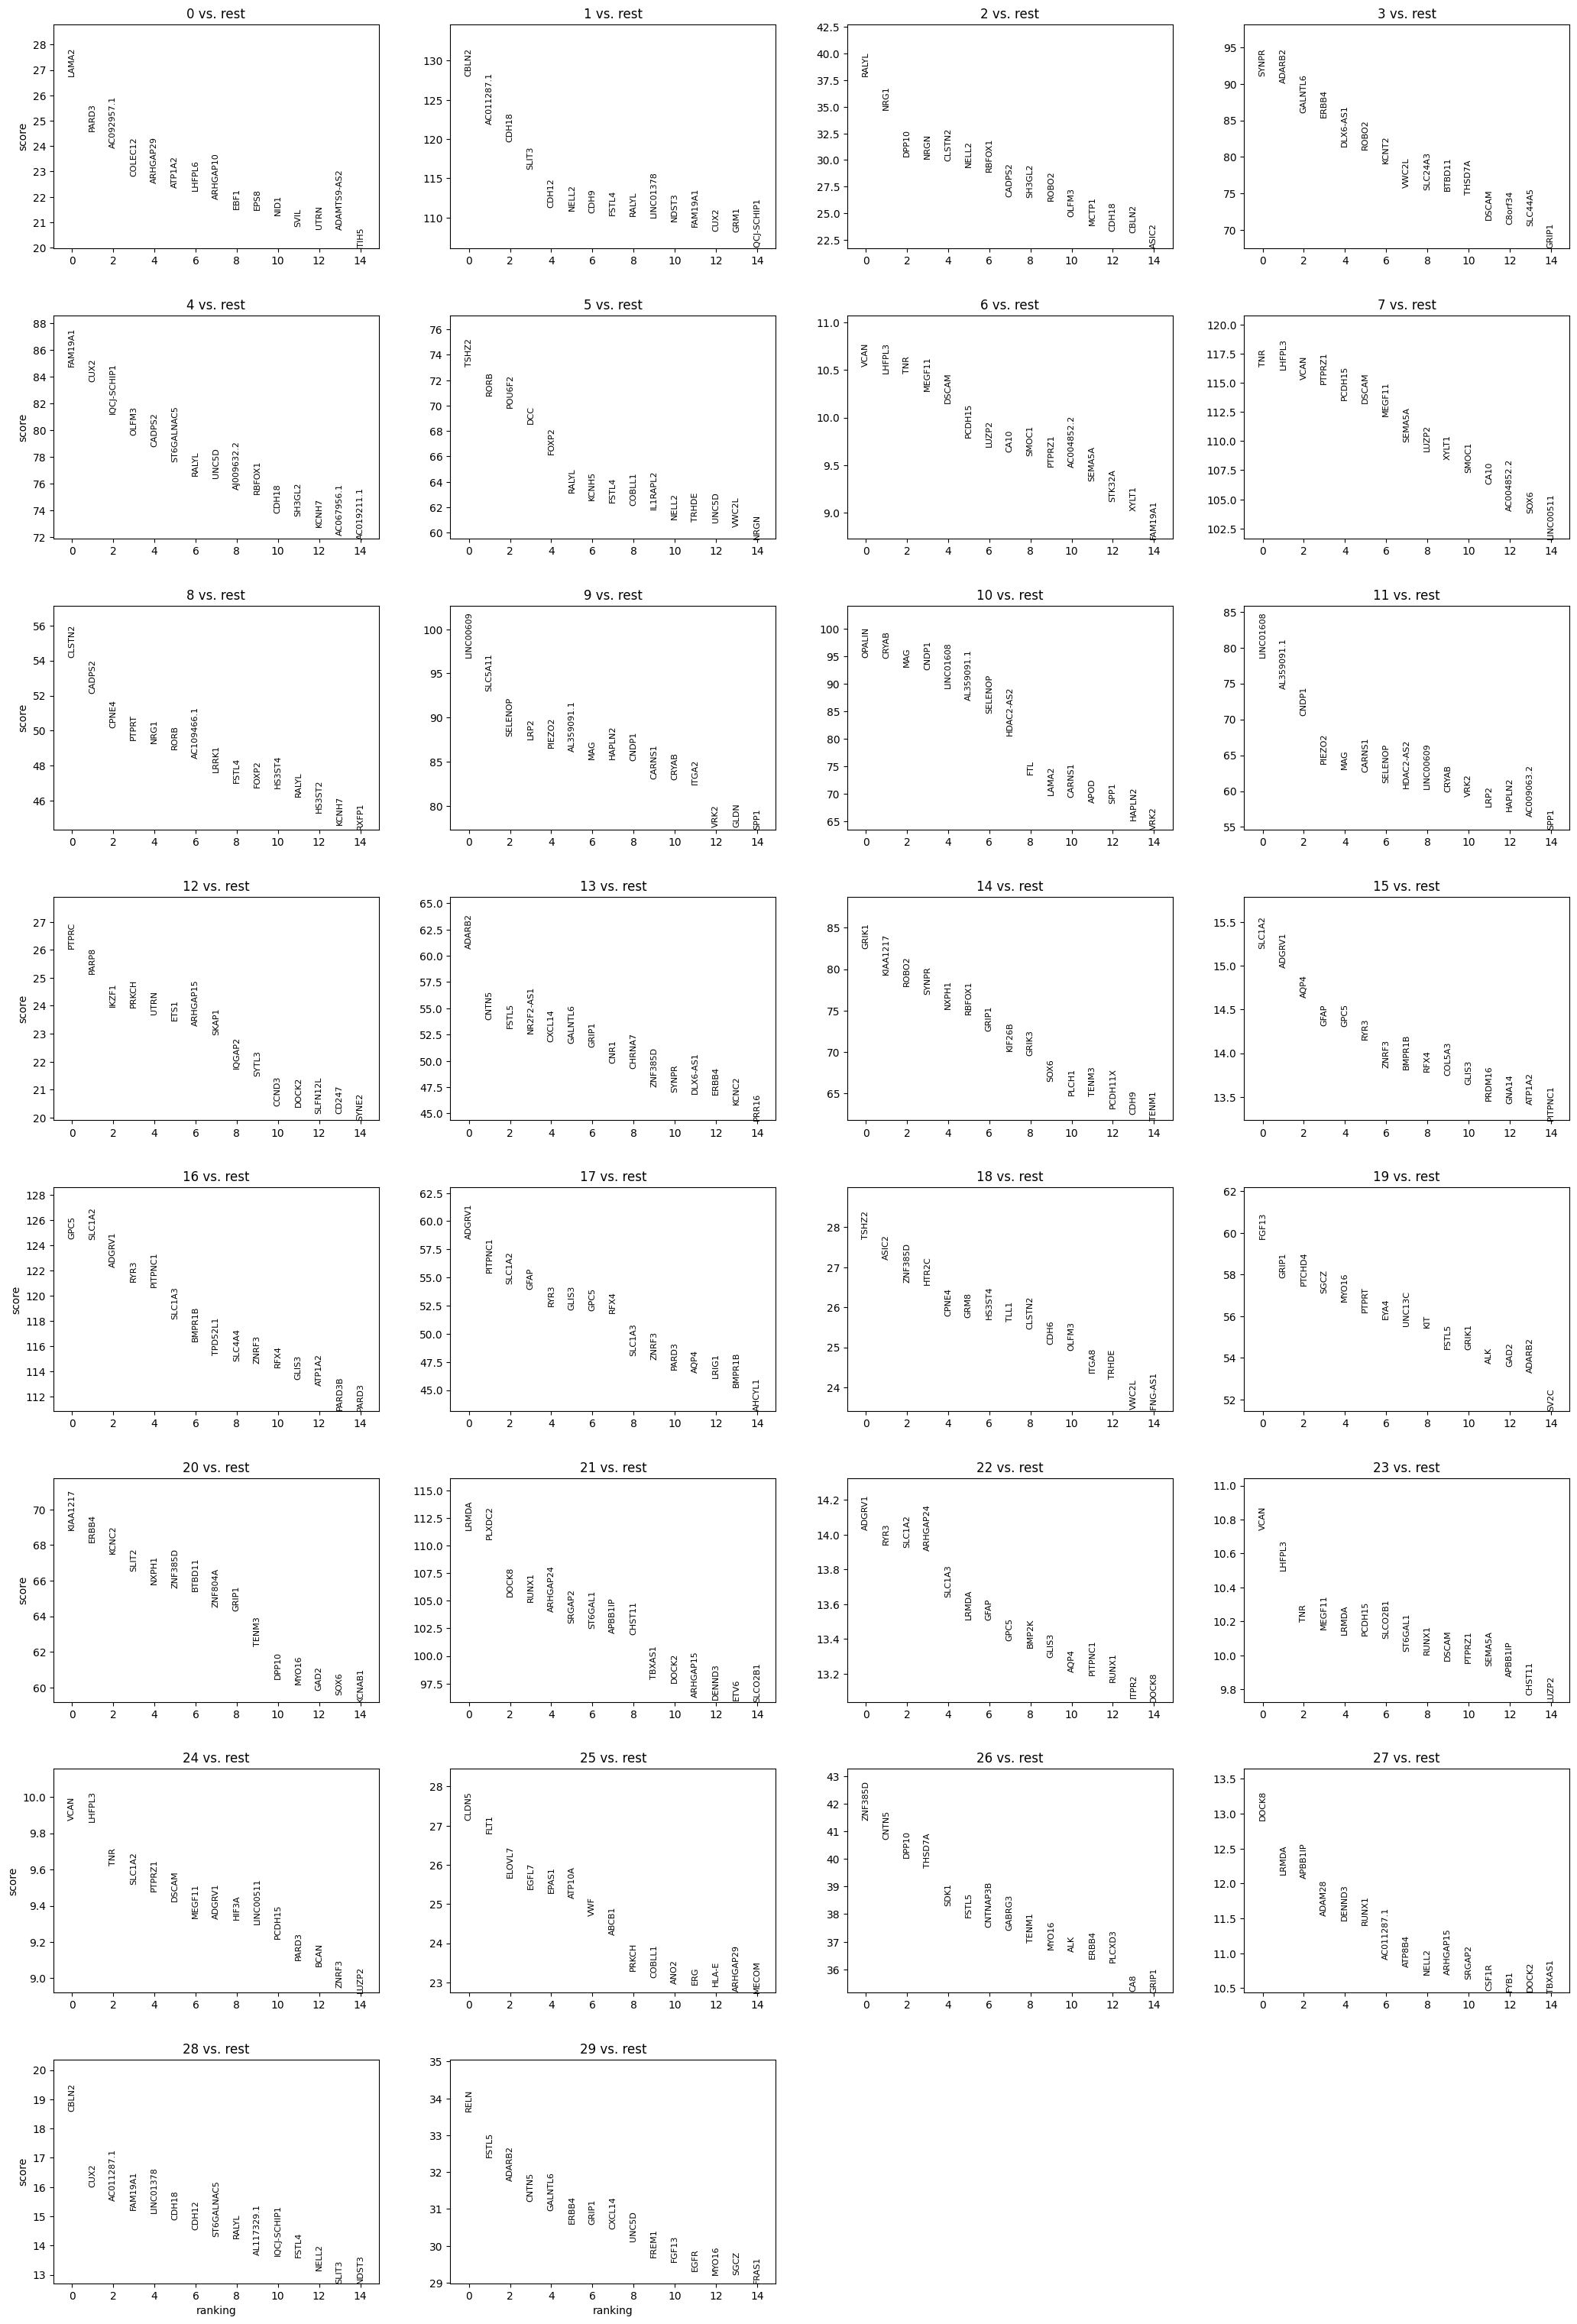

In [31]:
#View top markers per cluster
sc.pl.rank_genes_groups(
    adata,
    n_genes=15,
    sharey=False,
    key="rank_leiden"
)

**Interpretation:** This plot visualizes the top 15 marker genes for each Leiden cluster (total 30 clusters). It helps to quickly identify the most characteristic genes that define each cell population, providing insights into their unique biological identities.

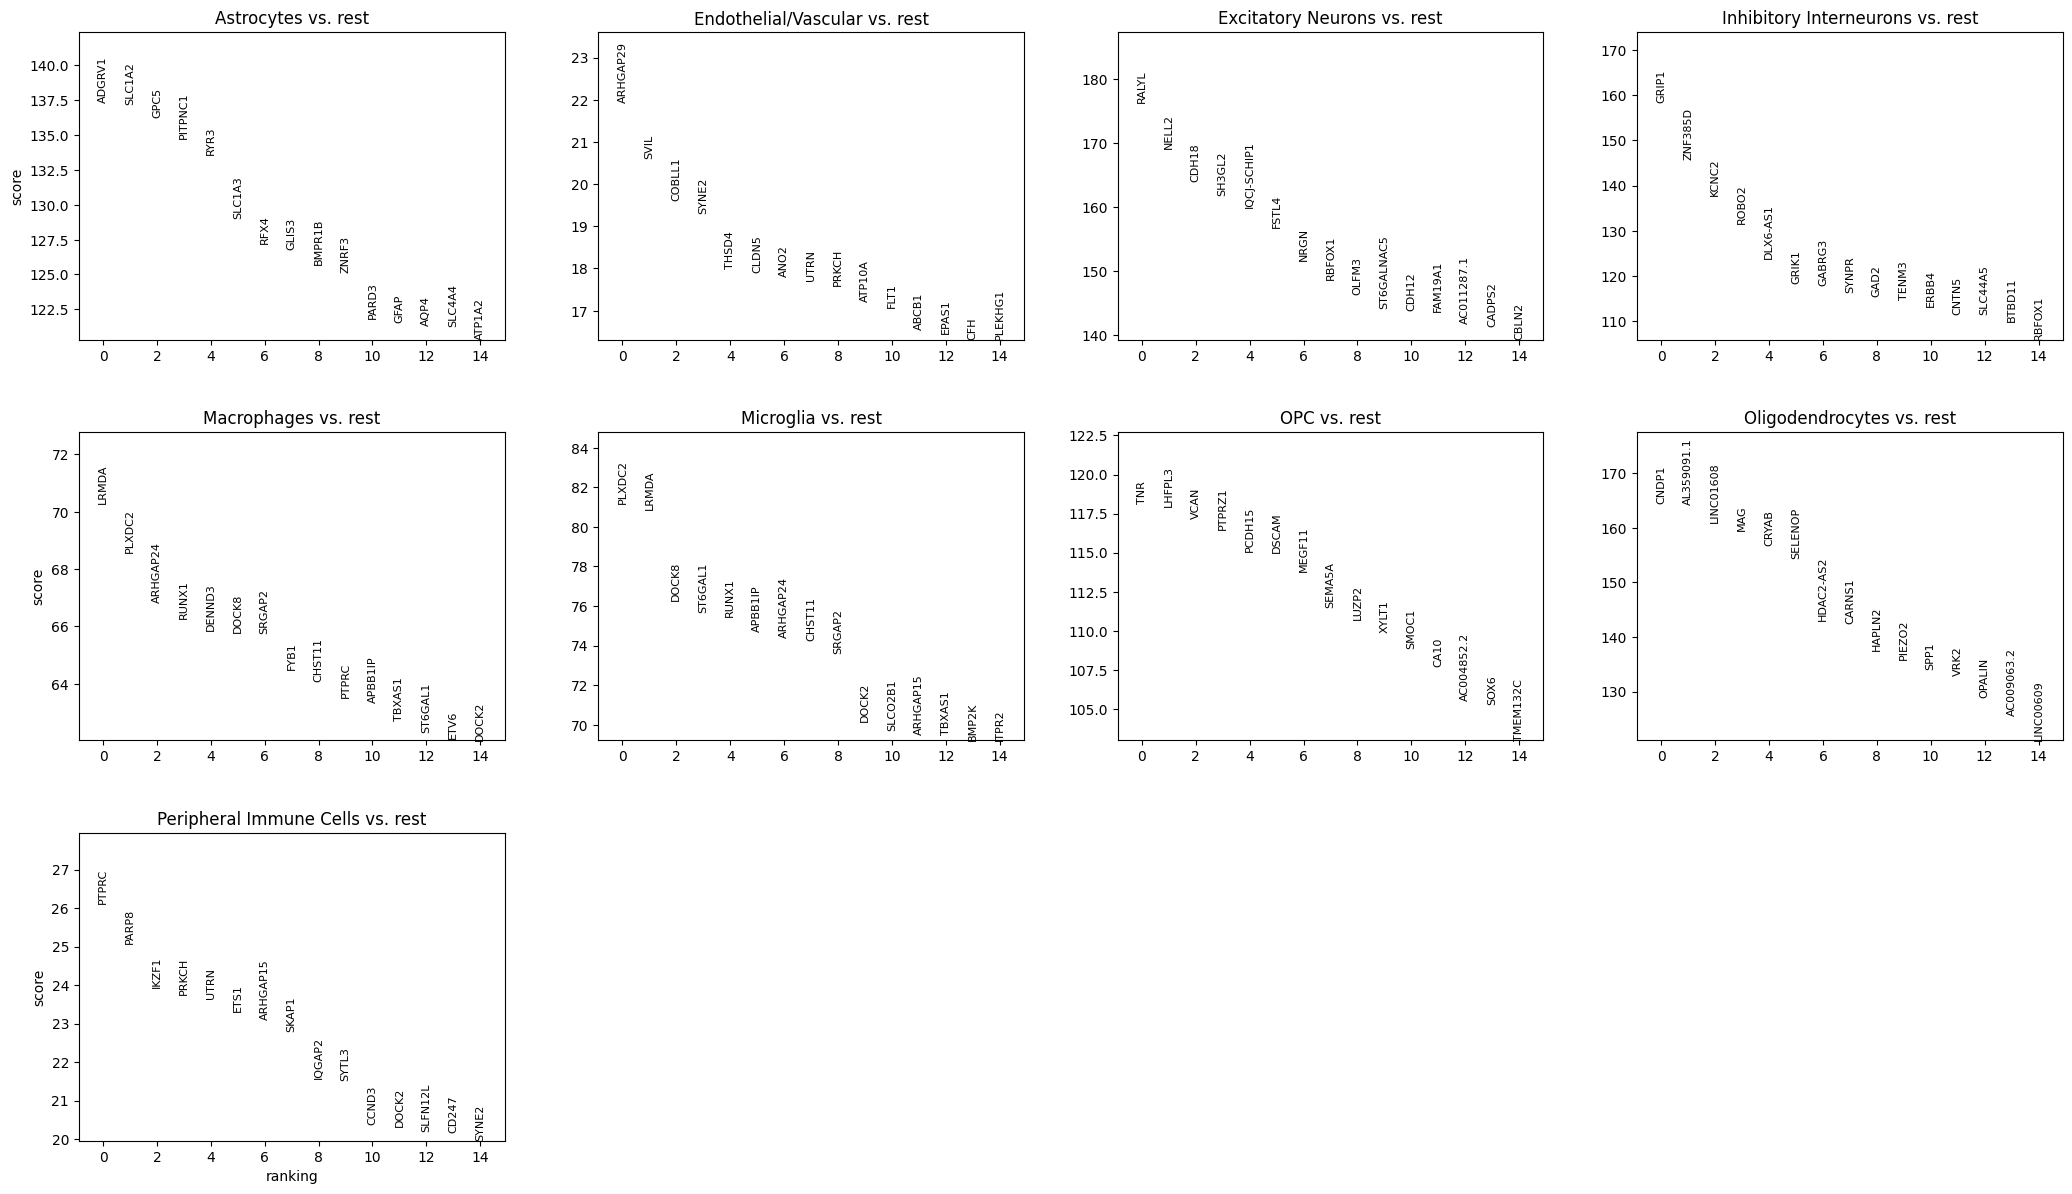

In [ ]:
# Plot top marker genes for major cell types
# Use this to visually validate the marker genes for each predicted cell type
sc.pl.rank_genes_groups(
    adata,
    n_genes=15,
    sharey=False,
    key="rank_cell_type"
)

**Interpretation:** This plot visualizes the top 15 marker genes for each major cell type (total 9 cell types). This helps to visually validate the marker genes for each predicted cell type, confirming their unique transcriptional signatures.

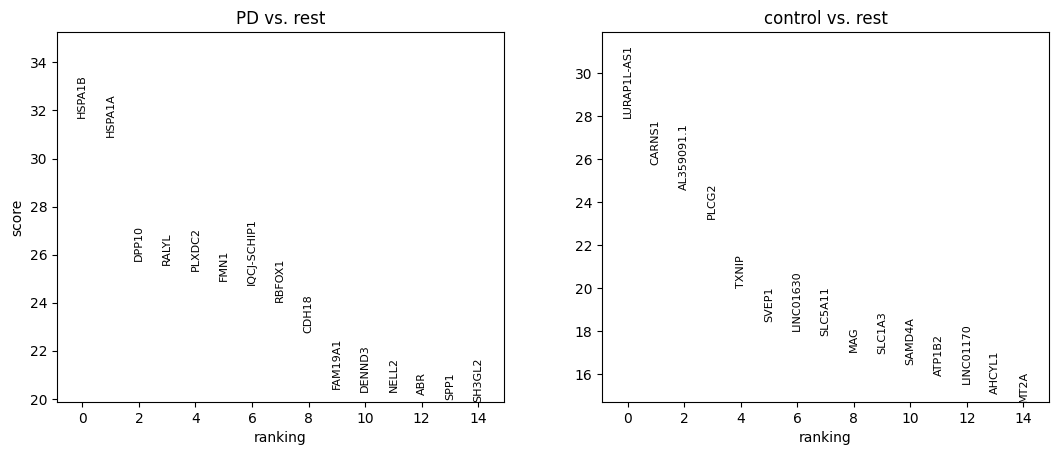

In [ ]:
sc.pl.rank_genes_groups(
    adata,
    n_genes=15,
    sharey=False,
    key="rank_condition"
)

**Interpretation:** Then, display visualization of the top 15 genes that are differentially expressed between the Parkinson's disease and control conditions. It can provide insights into potential disease-specific biomarkers or pathways.
- In the **PD vs. rest** panel, genes such as *HSPA1A*, *HSPA1B*, *DPP10*, and *RBFOX1* show the highest scores, indicating stronger association with Parkinson’s disease–related transcriptional changes. 
- In contrast, the **control vs. rest** panel highlights genes such as *LURAP1L-AS1*, *CARNS1*, and *PLCG2* as more characteristic of control samples. 
- The distinct gene rankings between the two panels demonstrate that PD and control conditions are driven by different transcriptional signatures, supporting the presence of condition‑specific molecular profiles.

Then, identify the most frequent (dominant) major cell type present within each Leiden cluster using a cross-tabulation. This allows for a biological annotation of the unsupervised Leiden clusters based on the CellTypist predictions.

In [ ]:
# Create a cross-tabulation of Leiden clusters vs. CellTypist cell types
cross_tab = pd.crosstab(adata.obs['leiden'], adata.obs['cell_major_class'])

# 2. For each Leiden cluster (row), find the cell type (column) with the maximum count
major_cell_type_per_cluster = cross_tab.idxmax(axis=1)

# 3. Print the results to see the mapping
print("Dominant cell type for each Leiden cluster:")
print(major_cell_type_per_cluster)

Dominant cell type for each Leiden cluster:
leiden
0        Endothelial/Vascular
1          Excitatory Neurons
2          Excitatory Neurons
3     Inhibitory Interneurons
4          Excitatory Neurons
5          Excitatory Neurons
6                         OPC
7                         OPC
8          Excitatory Neurons
9            Oligodendrocytes
10           Oligodendrocytes
11           Oligodendrocytes
12    Peripheral Immune Cells
13    Inhibitory Interneurons
14    Inhibitory Interneurons
15         Excitatory Neurons
16                 Astrocytes
17                 Astrocytes
18         Excitatory Neurons
19    Inhibitory Interneurons
20    Inhibitory Interneurons
21                  Microglia
22                 Astrocytes
23                        OPC
24                        OPC
25       Endothelial/Vascular
26    Inhibitory Interneurons
27         Excitatory Neurons
28         Excitatory Neurons
29    Inhibitory Interneurons
dtype: category
Categories (9, object): ['Astrocy

A new observation column, `leiden_cell_type`, is created by mapping each cell's Leiden cluster assignment to its dominant major cell type (determined in the previous step). It then prints the counts of these newly assigned cell types to confirm the mapping and show the distribution of major cell types across the dataset based on the Leiden clusters.

In [ ]:
# Create a new column in .obs to store the cell type per cluster
# This maps each cell's Leiden cluster number to the major cell type it belongs to
adata.obs['leiden_cell_type'] = adata.obs['leiden'].map(major_cell_type_per_cluster)

# 2. Print the top cell types to confirm the mapping
print(adata.obs['leiden_cell_type'].value_counts())

leiden_cell_type
Oligodendrocytes           22960
Excitatory Neurons         16417
Inhibitory Interneurons    11486
Astrocytes                  7683
OPC                         5131
Microglia                   4781
Endothelial/Vascular         625
Peripheral Immune Cells      256
Macrophages                    0
Name: count, dtype: int64


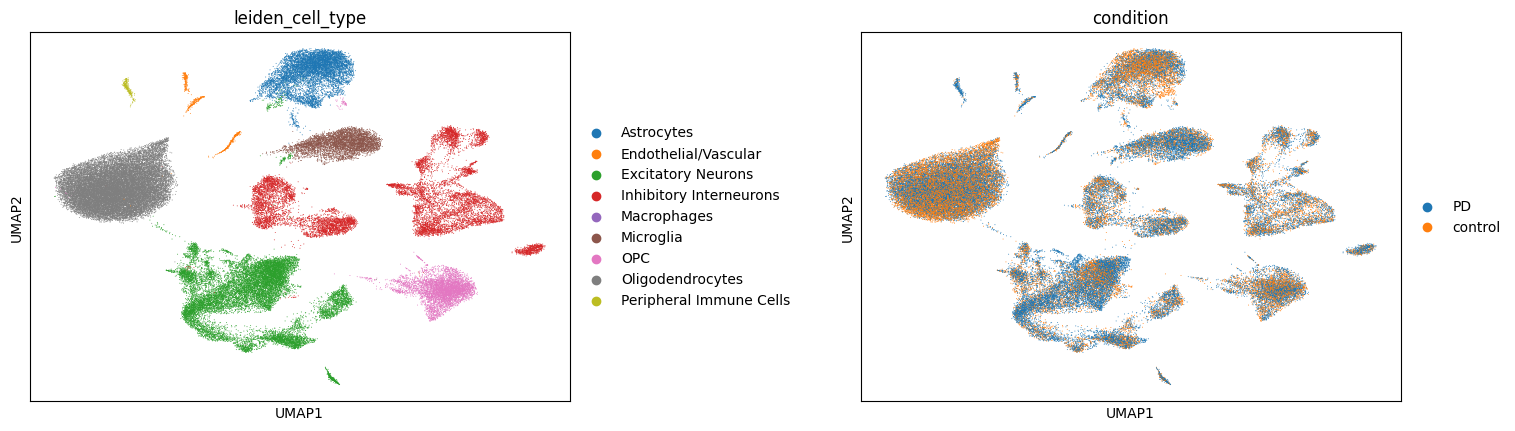

In [36]:
# Plot the UMAP using the newly assigned cell type names
sc.pl.umap(
    adata, 
    color=["leiden_cell_type", "condition"], 
    wspace=0.4
)

**Interpretation**
Major Populations: The largest clusters correspond to Oligodendrocytes (grey), Excitatory Neurons (green), Inhibitory Interneurons (red), and Astrocytes (blue).

Minor Populations: Smaller, distinct clusters are visible for Microglia (brown), OPCs (pink), Endothelial/Vascular cells (orange), Macrophages (purple), and Peripheral Immune Cells (light green).

Separation: The clear separation between most clusters indicates that the cell-type-specific expression signatures are well-defined, which validates the quality of the cell-type annotation step.

In [37]:
# Save dataset after clustering and ranking genes
adata.write("adata_after_clustering_and_ranking_genes.h5ad")

## 6. Differential Expression Analysis
Differential expression analyses were performed to identify cluster‑specific marker genes and to compare gene expression between Parkinson’s disease and control samples.


### Export Marker Genes

Cluster‑specific marker genes were extracted into a tabular format using get.rank_genes_groups_df, enabling easy inspection and downstream analysis of the top differentially expressed genes identified for each Leiden cluster.

In [38]:
# Extract cluster marker genes
cluster_gene_markers = sc.get.rank_genes_groups_df(
    adata,
    group=None,
    key="rank_leiden"
)

cluster_gene_markers.head()


,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,LAMA2,26.761164,NaN,9.155432e-158,1.831086e-154
1,0,PARD3,24.580269,NaN,2.053634e-133,2.053634e-130
2,0,AC092957.1,23.929573,NaN,1.508085e-126,1.005390e-123
3,0,COLEC12,22.816835,NaN,3.120869e-115,1.560434e-112
4,0,ARHGAP29,22.551044,NaN,1.311544e-112,5.246178e-110


In [39]:
#save cluster marker genes to CSV for downstream analysis
cluster_gene_markers.to_csv("DE_leiden_cluster_gene_markers_all_clusters.csv")

Now, The top differentially expressed genes for each Leiden cluster were extracted and displayed to examine the most strongly enriched marker genes characterizing each leiden cluster.

In [40]:
# Extract DE results
for cl in adata.obs["leiden"].cat.categories:
    print("\nCluster:", cl)
    print(
        sc.get.rank_genes_groups_df(
            adata,
            group=cl,
            key="rank_leiden"
        )[["names", "scores"]].head(10)
    )


Cluster: 0
        names     scores
0       LAMA2  26.761164
1       PARD3  24.580269
2  AC092957.1  23.929573
3     COLEC12  22.816835
4    ARHGAP29  22.551044
5      ATP1A2  22.358316
6      LHFPL6  22.233488
7    ARHGAP10  21.906126
8        EBF1  21.522467
9        EPS8  21.477221

Cluster: 1
        names      scores
0       CBLN2  128.031723
1  AC011287.1  121.890839
2       CDH18  119.667397
3       SLIT3  116.124672
4       CDH12  111.262138
5       NELL2  110.884087
6        CDH9  110.550682
7       FSTL4  110.325256
8       RALYL  110.231995
9   LINC01378  109.974838

Cluster: 2
    names     scores
0   RALYL  37.900162
1    NRG1  34.737823
2   DPP10  30.348064
3    NRGN  30.155224
4  CLSTN2  29.889698
5   NELL2  29.315981
6  RBFOX1  28.904751
7  CADPS2  26.560917
8  SH3GL2  26.497877
9   ROBO2  26.156868

Cluster: 3
      names     scores
0     SYNPR  91.063438
1    ADARB2  90.112091
2   GALNTL6  86.003273
3     ERBB4  85.447205
4  DLX6-AS1  81.444572
5     ROBO2  81.024048

I also extract the differentially expressed genes for each identified cell type into a pandas DataFrame. This allows for easy viewing and further analysis of the genes that are most characteristic of each cell population.

In [41]:
# Extract cluster marker genes
cell_type_gene_markers = sc.get.rank_genes_groups_df(
    adata,
    group=None,
    key="rank_cell_type"
)

cell_type_gene_markers.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,Astrocytes,ADGRV1,137.302933,NaN,0.0,0.0
1,Astrocytes,SLC1A2,137.166656,NaN,0.0,0.0
2,Astrocytes,GPC5,136.249939,NaN,0.0,0.0
3,Astrocytes,PITPNC1,134.752106,NaN,0.0,0.0
4,Astrocytes,RYR3,133.599655,NaN,0.0,0.0


In [43]:
#save cluster marker genes to CSV for downstream analysis
cell_type_gene_markers.to_csv("DE_cell_type_gene_markers.csv")

This prints the top 10 marker genes for that cell type. It helps to inspect the most characteristic genes that define each cell population, along with their scores and adjusted p-values.

In [ ]:
# View Top 10 Markers per cell type
for ct in adata.obs["leiden_cell_type"].cat.categories:
    print(f"\nTop 10 markers for cell type: {ct}")
    print(
        sc.get.rank_genes_groups_df(
            adata,
            group=ct,
            key="rank_cell_type"
        )[["names", "scores", "pvals_adj"]].head(10)
    )


Top 10 markers for cell type: Astrocytes
     names      scores  pvals_adj
0   ADGRV1  137.302933        0.0
1   SLC1A2  137.166656        0.0
2     GPC5  136.249939        0.0
3  PITPNC1  134.752106        0.0
4     RYR3  133.599655        0.0
5   SLC1A3  129.000336        0.0
6     RFX4  127.212585        0.0
7    GLIS3  126.756775        0.0
8   BMPR1B  125.683685        0.0
9    ZNRF3  125.127396        0.0

Top 10 markers for cell type: Endothelial/Vascular
      names     scores      pvals_adj
0  ARHGAP29  21.922955  3.138726e-103
1      SVIL  20.615509   1.992195e-91
2    COBLL1  19.600302   7.685516e-83
3     SYNE2  19.298933   2.193147e-80
4     THSD4  18.005692   5.859680e-70
5     CLDN5  17.890123   4.022753e-69
6      ANO2  17.794930   1.934129e-68
7      UTRN  17.712301   7.489089e-68
8     PRKCH  17.583845   6.551800e-67
9    ATP10A  17.203531   4.542347e-64

Top 10 markers for cell type: Excitatory Neurons
         names      scores  pvals_adj
0        RALYL  176.216812

Now, Genes differentially expressed between Parkinson’s Disease and control samples are identified and visualize.

In [45]:
#Check condition labels
adata.obs["condition"].value_counts()

condition
PD         38312
control    31027
Name: count, dtype: int64

Then, extracts the differentially expressed (DE) genes between Parkinson's Disease (PD) and control samples into a pandas DataFrame. It retrieves the results of the `rank_genes_groups` analysis for all conditions and displays the top entries.

In [47]:
# Extract DE results
de_results_PD_and_control = sc.get.rank_genes_groups_df(adata, group=None, key="rank_condition")
de_results_PD_and_control.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,PD,HSPA1B,31.710018,NaN,1.130554e-220,2.261107e-217
1,PD,HSPA1A,30.883043,NaN,2.017845e-209,2.017845e-206
2,PD,DPP10,25.733936,NaN,4.877226e-146,1.950890e-143
3,PD,RALYL,25.587143,NaN,2.121067e-144,7.070223e-142
4,PD,PLXDC2,25.324213,NaN,1.728965e-141,4.939901e-139


In [48]:
# Save the DE results to CSV for both conditions
de_results_PD_and_control.to_csv("DE_PD_vs_control_all_genes.csv")

Then, extract the differentially expressed (DE) genes specifically for the Parkinson's Disease (PD) group into a pandas DataFrame, which will be useful for downstream analysis. 


In [49]:
# Extract DE results for PD
de_results_PD = sc.get.rank_genes_groups_df(adata, group="PD", key="rank_condition")
de_results_PD.head()

,names,scores,logfoldchanges,pvals,pvals_adj
0,HSPA1B,31.710018,NaN,1.130554e-220,2.261107e-217
1,HSPA1A,30.883043,NaN,2.017845e-209,2.017845e-206
2,DPP10,25.733936,NaN,4.877226e-146,1.950890e-143
3,RALYL,25.587143,NaN,2.121067e-144,7.070223e-142
4,PLXDC2,25.324213,NaN,1.728965e-141,4.939901e-139


In [50]:
# Save the DE results for PD to CSV for further analysis
de_results_PD.to_csv("DE_results_PD_all_genes.csv")

#### Marker Genes of cell types in Parkinson's Disease
Then, Cell types and marker genes of each type in only Parkinson's disease sample will be studied. For this,  **subsets the AnnData object** to include only cells from Parkinson's Disease (PD) samples. Then, it **counts and displays the distribution of major cell types** specifically within these PD samples, providing insight into their cellular composition.

In [ ]:
# Subset the original AnnData to keep only the PD samples
adata_pd = adata[adata.obs["condition"] == "PD"].copy()

# Check which cell types are present in your PD samples
print("Cell types present in the PD samples:")
print(adata_pd.obs["cell_major_class"].value_counts())

Cell types present in the PD samples:
cell_major_class
Oligodendrocytes           12168
Excitatory Neurons         10134
Inhibitory Interneurons     6073
Astrocytes                  3520
OPC                         2711
Macrophages                 1754
Microglia                   1340
Endothelial/Vascular         389
Peripheral Immune Cells      223
Name: count, dtype: int64


In [ ]:
# Compute marker genes per cell type within the PD samples
# We use Wilcoxon rank-sum test to compare genes in one cell type vs all other cell types *in PD*
sc.tl.rank_genes_groups(
    adata_pd, 
    groupby="leiden_cell_type", 
    method="wilcoxon",
    key_added="rank_pd_cell_types"
)

This visualizes the top 15 marker genes for each cell type *specifically within the Parkinson's Disease (PD) samples*.

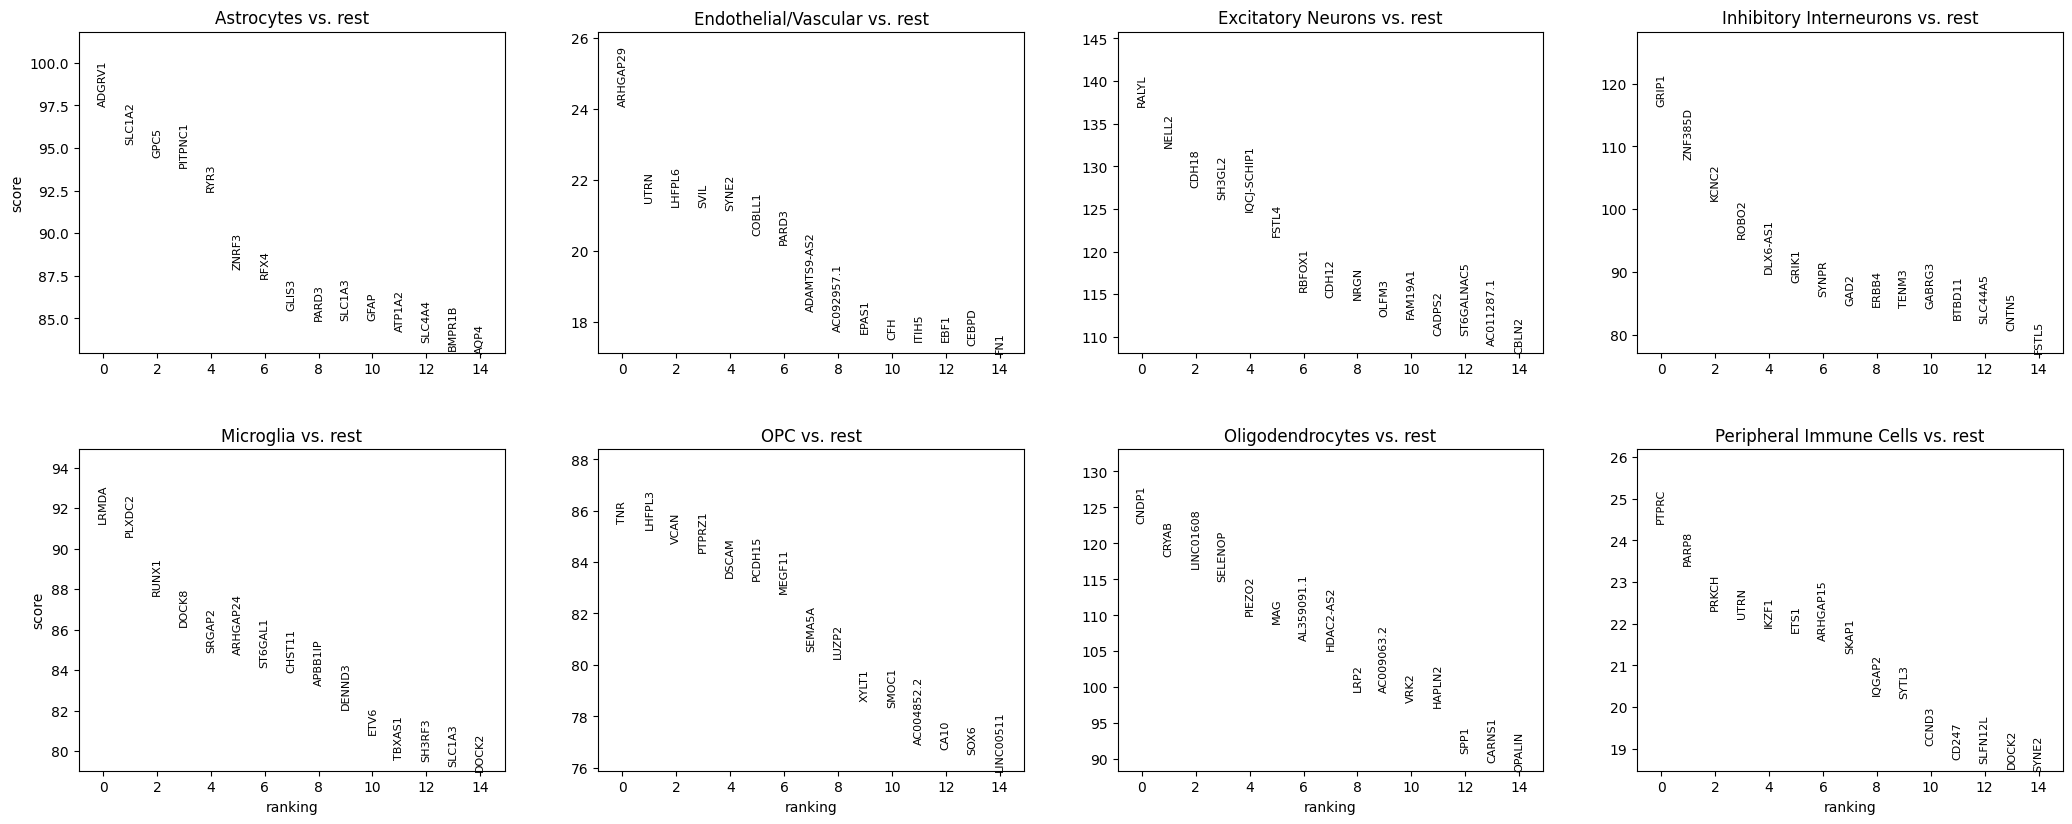

In [ ]:
# Plot the top markers for all cell types in PD samples only
sc.pl.rank_genes_groups(
    adata_pd, 
    n_genes=15, 
    sharey=False, 
    key="rank_pd_cell_types"
)

Then, extract the differentially expressed genes for each cell type *specifically within the Parkinson's Disease (PD) samples* into a pandas DataFrame.

In [55]:
cell_type_gene_markers_PD = sc.get.rank_genes_groups_df(adata_pd, group=None, key="rank_pd_cell_types")
cell_type_gene_markers_PD.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,Astrocytes,ADGRV1,97.484657,NaN,0.0,0.0
1,Astrocytes,SLC1A2,95.222328,NaN,0.0,0.0
2,Astrocytes,GPC5,94.469749,NaN,0.0,0.0
3,Astrocytes,PITPNC1,93.865196,NaN,0.0,0.0
4,Astrocytes,RYR3,92.484901,NaN,0.0,0.0


In [56]:
cell_type_gene_markers_PD.to_csv("DE_cell_type_gene_markers_PD_only.csv")

### Volcano Plot and Significant Gene Selection

A volcano plot was generated to visualize differential gene expression between Parkinson’s disease and control samples by plotting log2 fold changes against the negative log10‑transformed adjusted p‑values, enabling rapid identification of significantly regulated genes.

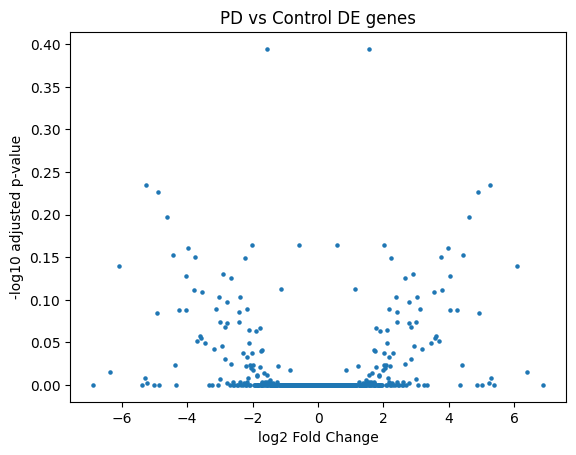

In [57]:
#import required libraries
import numpy as np
import matplotlib.pyplot as plt

# Create a copy of the DataFrame for plotting
df = de_results_PD_and_control.copy()

#Volcano plot
plt.scatter(
    df["logfoldchanges"],
    -np.log10(df["pvals_adj"]),
    s=5
)

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10 adjusted p-value")
plt.title("PD vs Control DE genes")
plt.show()

- In a volcano plot, higher values on the y‑axis (−log10 adjusted p‑value) indicate **greater statistical significance**.
- Genes farther to the left or right on the x‑axis show **larger decreases or increases in expression**, respectively.
- Genes appearing toward the **top corners of the plot** represent the most biologically relevant candidates, as they combine large fold changes with high statistical significance.

Although several genes display substantial fold changes in both directions, only a limited number achieve strong statistical significance, as indicated by the small number of genes with high −log10 adjusted p‑values. This suggests that Parkinson’s disease–associated transcriptional alterations are present

## 7. Gene Enrichment Analysis

Genes with an adjusted p‑value below 0.05 were selected as statistically significant differentially expressed genes in Parkinson’s disease, and the total number of such genes was quantified for downstream analysis.

In [58]:
# Significant genes
sig = de_results_PD[de_results_PD["pvals_adj"] < 0.05]
gene_list = sig["names"].tolist()
len(gene_list)

748

There are 748 significant genes in Parkinson Disease samples.

In [59]:
#Export gene list to text file for downstream analysis
sig["names"].to_csv("PD_significant_genes.txt", index=False, header=False)

Then, I will select significant genes of each cell type of PD samples. 

In [77]:
#find the cell types associated with the significant genes
cell_type_gene_markers['group'].unique()

['Astrocytes', 'Endothelial/Vascular', 'Excitatory Neurons', 'Inhibitory Interneurons', 'Macrophages', 'Microglia', 'OPC', 'Oligodendrocytes', 'Peripheral Immune Cells']
Categories (9, object): ['Astrocytes', 'Endothelial/Vascular', 'Excitatory Neurons', 'Inhibitory Interneurons', ..., 'Microglia', 'OPC', 'Oligodendrocytes', 'Peripheral Immune Cells']

Then, extract and save lists of statistically significant genes for each major cell type found in Parkinson's Disease (PD) samples. It processes each cell type, identifies genes with an adjusted p-value less than 0.05, and then writes these genes to a text file, organized by cell type.

In [61]:
# 1. List of your cell types
cell_types = [
    'Astrocytes', 'Endothelial/Vascular', 'Excitatory Neurons', 'Inhibitory Interneurons', 'Macrophages', 'Microglia', 'OPC', 'Oligodendrocytes', 'Peripheral Immune Cells'
]

print("Processing PD samples and counting significant genes:")
print("-" * 65)

# 2. Open a text file to write the output
with open("significant_genes_by_cell_type_PD.txt", "w") as f:
    for ct in cell_types:
        # Filter the dataframe for the specific cell type and pvals_adj < 0.05
        sig_subset = cell_type_gene_markers_PD[
            (cell_type_gene_markers_PD["group"] == ct) & 
            (cell_type_gene_markers_PD["pvals_adj"] < 0.05)
        ]
        
        # Extract just the gene names as a list
        gene_list = sig_subset["names"].tolist()
        
        # Print the count directly in your notebook
        print(f"{ct:<30} | {len(gene_list)} genes extracted")
        
        # Write the cell type name as the header line
        f.write(f"{ct}\n")
        
        # Write each gene name directly underneath it
        for gene in gene_list:
            f.write(f"{gene}\n")
            
        # Add an empty line to separate this cell type from the next one
        f.write("\n")

print("-" * 65)
print("File 'significant_genes_by_cell_type_PD.txt' has been created successfully!")

Processing PD samples and counting significant genes:
-----------------------------------------------------------------
Astrocytes                     | 971 genes extracted
Endothelial/Vascular           | 730 genes extracted
Excitatory Neurons             | 1094 genes extracted
Inhibitory Interneurons        | 994 genes extracted
Macrophages                    | 0 genes extracted
Microglia                      | 1224 genes extracted
OPC                            | 883 genes extracted
Oligodendrocytes               | 1230 genes extracted
Peripheral Immune Cells        | 658 genes extracted
-----------------------------------------------------------------
File 'significant_genes_by_cell_type_PD.txt' has been created successfully!


Significant genes in PD samples and also the significant genes of each cell type of PD samples were uploaded *separately* to the g:Profiler web server (https://biit.cs.ut.ee/gprofiler/gost), the organism was set to *Homo sapiens*, and functional enrichment analysis was performed to identify over‑represented gene ontology terms and pathways.

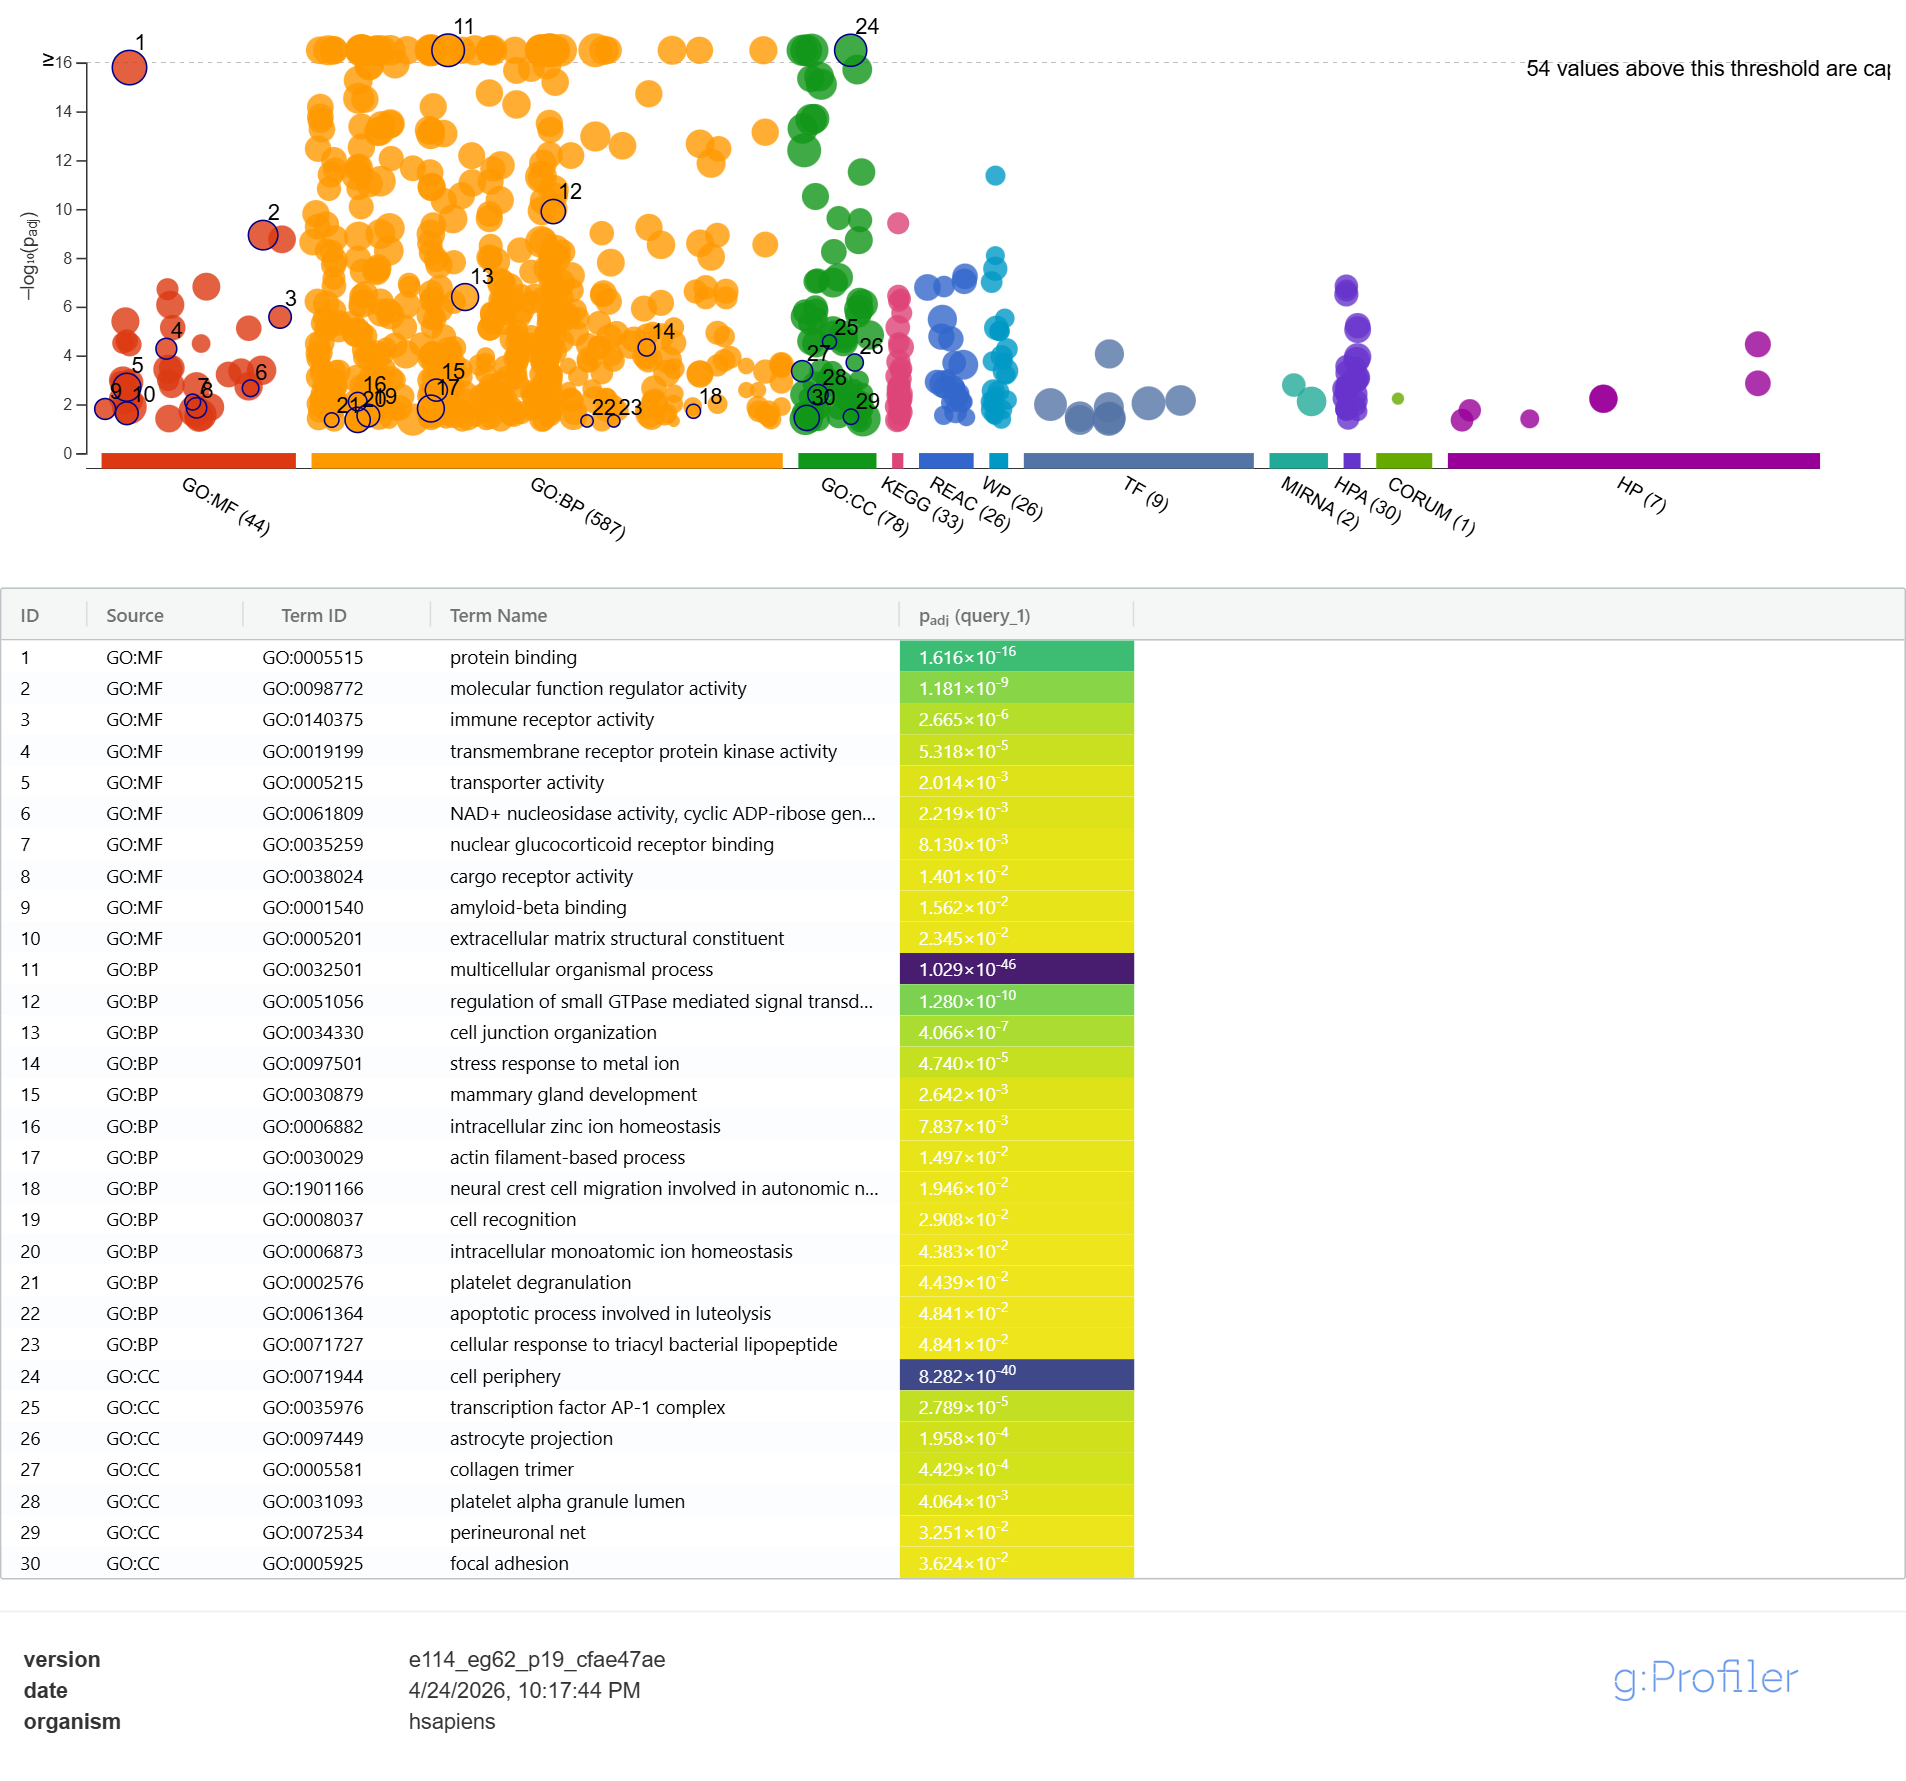

**Interpretation**

Gene ontology and pathway enrichment analysis of the significantly differentially expressed genes using g:Profiler revealed strong enrichment for multiple biological processes, molecular functions, and cellular components. 

Notably, significant enrichment in GO Biological Processes (including signal transduction, ion homeostasis, and stress responses) indicates widespread functional alterations in Parkinson’s disease. 

In GO Molecular Functions, enriched terms like protein and immune receptor binding point to dysregulated inflammatory and signaling mechanisms. 

Furthermore, GO Cellular Components (such as cell periphery, astrocyte projections, and focal adhesions) highlight structural remodeling and glial involvement. 

Together, these results confirm that PD-associated transcriptional changes are driven by interconnected neuroinflammatory, signaling, and structural disruptions.


The results of the significant genes across different cell types in Parkinson's Disease (PD) samples are described and interpreted in the accompanying notebook, **[Functional Enrichment Analysis.ipynb](Functional%20Enrichment%20Analysis.ipynb)**, for better visibility and clarity.

In [62]:
# Summary statistics of p-values
de_results_PD["pvals"].describe()

count     2.000000e+03
mean      4.063438e-01
std       4.118111e-01
min      1.130554e-220
25%       3.786179e-05
50%       2.447278e-01
75%       8.837027e-01
max       9.997128e-01
Name: pvals, dtype: float64

The summary statistics of raw p‑values show that while most genes are not significantly differentially expressed (median p‑value ≈ 0.24)

A subset of genes exhibits extremely low p‑values, indicating strong evidence of differential expression between PD and control samples. 

The wide spread of p‑values, ranging from near zero to nearly one, reflects substantial heterogeneity in gene‑level significance, which is expected in genome‑wide differential expression analyses.



## 8. Machine Learning Classification

A Random Forest classifier is trained using
top differentially expressed genes to predict
PD vs control samples.

In [63]:
#import required libraries for machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve


In [64]:

# Select top 50 genes by adjusted p-value and sort by adjusted p-value
top50 = (
    de_results_PD_and_control
    .copy()
    .sort_values("pvals_adj")
    .head(50)["names"]
    .tolist()
)

In [65]:
# extract expression matrix for selected genes
X = adata[:, top50].X

# convert to dense if sparse
if not isinstance(X, np.ndarray):
    X = X.toarray()

# labels
y = adata.obs["condition"].values

In [66]:
# Encode labels
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)  # PD=1, Control=0 (or vice versa)

In [67]:
#Train / test    split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [68]:
#Train the Random Forest model
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [69]:
# Make predictions on test set
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

In [70]:
#Evaluate with multiple metrics (accuracy, F1 score, ROC-AUC)
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_prob)

print(f"Test Accuracy: {acc:.3f}")
print(f"Test F1 Score: {f1:.3f}")
print(f"Test ROC-AUC: {auc_score:.3f}")

Test Accuracy: 0.749
Test F1 Score: 0.708
Test ROC-AUC: 0.831


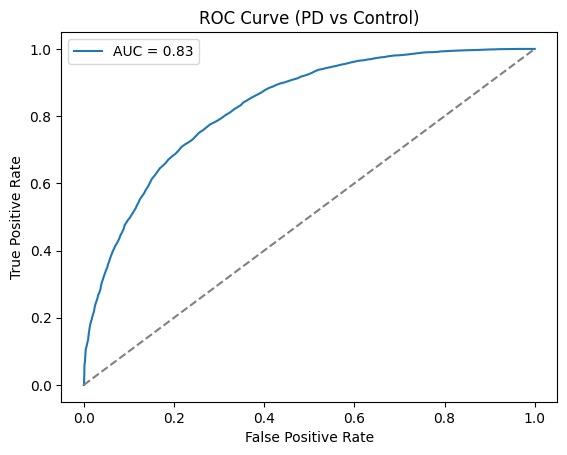

In [71]:
#Plot ROC curve
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (PD vs Control)")
plt.legend()
plt.show()


- The Random Forest model achieved a test accuracy of 74.9%, indicating that the majority of cells were correctly classified as Parkinson’s disease or control.  
- An F1 score of 0.708 suggests a balanced performance between precision and recall, reflecting reasonable robustness in handling class imbalance.  
- The ROC‑AUC score of 0.831 indicates strong discriminative ability, demonstrating that the model effectively distinguishes between PD and control samples - based on gene expression patterns.
- Overall, the model demonstrates a strong predictive signal in gene expression data for distinguishing Parkinson’s disease from control samples, 


### Feature Importance Analysis

Top genes contributing to disease prediction
are ranked based on Random Forest importance scores.

In [72]:
#feature importance
rf.fit(X, y_encoded)
importances = rf.feature_importances_

importance_df = (
    pd.DataFrame({
        "gene": top50,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
)

importance_df.head(10)

,gene,importance
22,PLCG2,0.032790
21,RBFOX1,0.032468
23,PLCG2,0.032436
20,RBFOX1,0.030824
3,HSPA1A,0.030127
9,DPP10,0.030051
13,PLXDC2,0.030050
12,PLXDC2,0.029822
7,DPP10,0.029771
2,HSPA1A,0.029378


In [73]:
importance_df.to_csv("gene_importance_random_forest.csv", index=False)

- The feature importance analysis indicates that genes such as PLCG2, RBFOX1, PLXDC2, HSPA1A, and DPP10 contribute most strongly to the Random Forest model’s predictions. 

- The similar importance values suggest that disease classification is driven by the combined contribution of multiple genes, rather than reliance on a single dominant marker, reflecting the polygenic and heterogeneous nature of Parkinson’s disease–associated transcriptional changes.



- The overlap of RBFOX1, PLXDC2, HSPA1A, and DPP10 among the top Random Forest features and the highest‑ranking genes in the PD vs. rest analysis indicates that these genes are both statistically differentially expressed and highly informative for classification, suggesting they represent robust transcriptional signatures associated with Parkinson’s disease.

- these genes are robust candidate biomarkers for Parkinson’s disease, although further validation in independent datasets would be required to confirm their biomarker potential.



## Conclusion

In this study, single‑cell RNA‑sequencing data from the GSE202210 dataset were analyzed to characterize transcriptional alterations associated with Parkinson’s disease. Through quality control, normalization, dimensionality reduction, and Leiden clustering, distinct cellular populations were identified, revealing both shared and PD‑enriched transcriptional states. Differential expression and gene enrichment analyses highlighted pathways related to immune signaling, stress responses, ion homeostasis, and cellular structural components, consistent with the complex and multifactorial nature of PD pathology. Furthermore, machine‑learning modeling using a Random Forest classifier demonstrated strong discriminatory power between PD and control samples, with feature importance analysis identifying key genes contributing to disease classification. Overall, this integrated single‑cell, statistical, and machine‑learning approach provides insights into PD‑associated molecular signatures and identifies candidate genes and biological processes for further investigation and validation.

